In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

# 데이터 불러오기
original = pd.read_csv('c:\python\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_40주차
      연도주차    단가         신고중량
194  20_42 0.273  5892192.336
195  20_43 0.276  8621320.361
196  20_44 0.277 10201257.261
197  20_45 0.278  8196479.362
198  20_46 0.281  6882415.227
199  20_47 0.284  8418110.158
200  20_48 0.285  7855938.056
201  20_49 0.285  8487338.055
202  20_50 0.287  8919522.904
203  20_51 0.287  4435313.673
204  20_52 0.302  6660056.188
205  20_53 0.307  6811887.337
206  21_01 0.308  7471432.525
207  21_02 0.310  7864346.467
208  21_03 0.304  5347890.630
209  21_04 0.304  7432961.455
210  21_05 0.306  8070404.966
211  21_06 0.310  8843312.073
212  21_07 0.312 

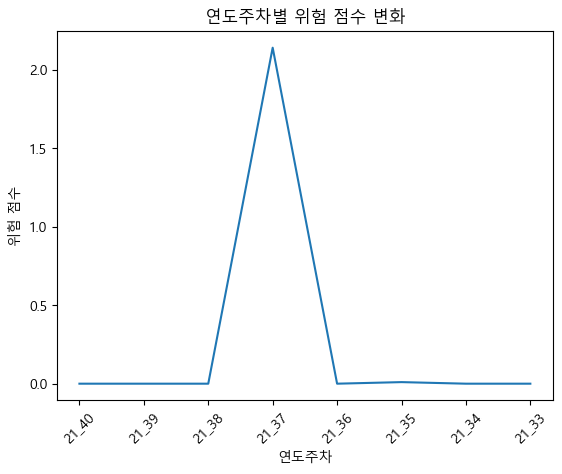

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_30주차
      연도주차      단가      신고중량
79   18_31 232.394 23492.327
80   18_32 239.664 25873.863
81   18_33 243.658 23569.524
82   18_34 241.069 23905.783
83   18_35 270.627 22048.571
84   18_36 241.770 23912.596
85   18_37 275.102 22698.219
86   18_38 270.882 23856.776
87   18_39 274.426 21067.980
88   18_40 273.856 20785.282
89   18_41 243.639 27609.976
90   18_42 240.823 27166.385
91   18_43 231.794 30817.958
92   18_44 251.146 26050.878
93   18_45 277.998 22238.050
94   18_46 272.614 23637.975
95   18_47 292.676 22112.843
96   18_48 274.076 23692.447
97   18_49 287.220 24448.219
98   18_50 326.250 

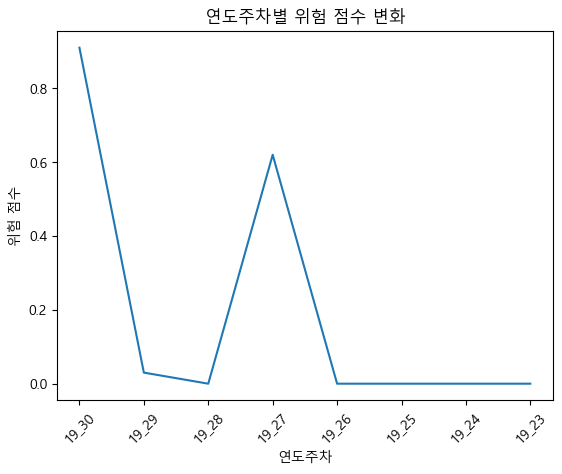

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
21_14주차
      연도주차    단가       신고중량
168  20_16 1.168 232849.132
169  20_17 1.273 208142.443
170  20_18 1.278 212974.443
171  20_19 1.296 174660.487
172  20_20 1.307 192153.237
173  20_21 1.282 174147.462
174  20_22 1.246 208127.462
175  20_23 1.225 197927.225
176  20_24 1.222 169040.725
177  20_25 1.217 189372.250
178  20_26 1.240 165649.963
179  20_27 1.241 171324.713
180  20_28 1.239 171240.088
181  20_29 1.256 180231.838
182  20_30 1.291 141282.547
183  20_31 1.279 167364.547
184  20_32 1.276 177168.922
185  20_33 1.256 156222.672
186  20_34 1.236 213491.250
187  20_35 1.272 192786.750
188  20_36 1.268 188341

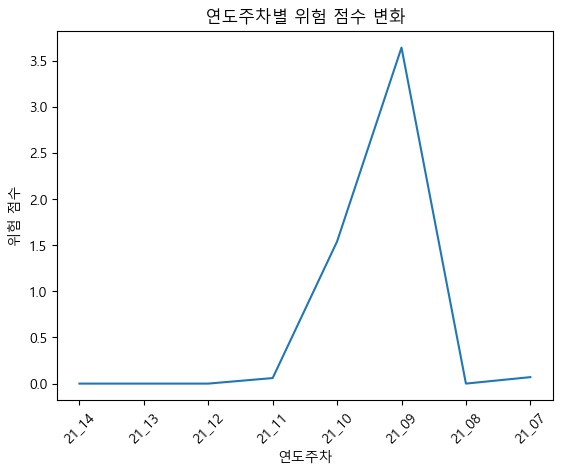

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_45주차
      연도주차    단가        신고중량
199  20_47 1.529 1838912.570
200  20_48 1.524 1881359.907
201  20_49 1.523 2331514.192
202  20_50 1.519 2123058.496
203  20_51 1.540 1726439.953
204  20_52 1.577 2127137.453
205  20_53 1.619 1450353.759
206  21_01 1.670 1715679.800
207  21_02 1.729 1913412.288
208  21_03 1.849 1845113.619
209  21_04 1.911 1992666.875
210  21_05 1.981 1927276.746
211  21_06 2.053 1775287.477
212  21_07 2.281 1647085.896
213  21_08 2.331 2087361.094
214  21_09 2.448 1930276.436
215  21_10 2.445 1892042.360
216  21_11 2.461 2327552.947
217  21_12 2.481 2080499.897
218  21_13 2.490 19

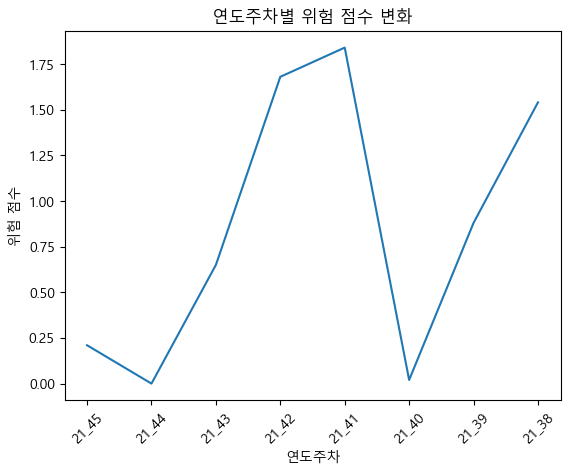

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_51주차
      연도주차    단가          신고중량
205  20_53 0.103 225731607.798
206  21_01 0.107 183787999.567
207  21_02 0.107 224709651.750
208  21_03 0.110 202500680.500
209  21_04 0.113 217664043.000
210  21_05 0.116 242124105.935
211  21_06 0.116 234179063.435
212  21_07 0.126 209051809.935
213  21_08 0.122 270433729.435
214  21_09 0.119 246078410.135
215  21_10 0.127 236893702.635
216  21_11 0.123 274214557.385
217  21_12 0.136 221917945.020
218  21_13 0.134 306853383.385
219  21_14 0.131 279513383.385
220  21_15 0.127 233950465.885
221  21_16 0.116 161579432.000
222  21_17 0.115 

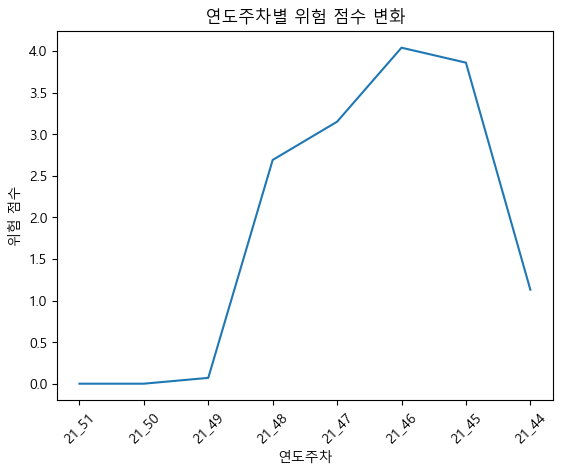

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_51주차
      연도주차    단가       신고중량
205  20_53 2.941 254742.525
206  21_01 3.446 178310.470
207  21_02 3.332 196105.482
208  21_03 3.499 147182.957
209  21_04 3.310 187867.957
210  21_05 2.799 262452.513
211  21_06 2.863 280122.500
212  21_07 2.831 252057.500
213  21_08 2.821 253210.000
214  21_09 2.890 211705.000
215  21_10 2.824 222757.500
216  21_11 2.865 283655.000
217  21_12 2.883 246677.500
218  21_13 2.876 237352.500
219  21_14 2.908 224752.500
220  21_15 2.917 209272.500
221  21_16 2.906 171292.500
222  21_17 2.891 187030.000
223  21_18 2.912 150935.000
224  21_19 2.931 106027.500
225  21_20 2.909 161752

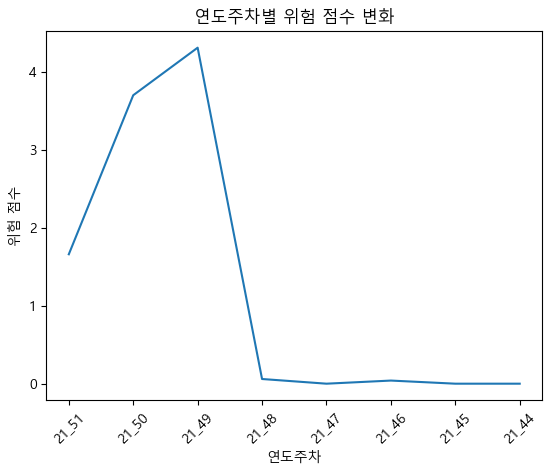

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
22_02주차
      연도주차    단가        신고중량
209  21_04 0.938 1655937.250
210  21_05 0.929  901391.250
211  21_06 0.964  973333.000
212  21_07 0.970 1148300.000
213  21_08 1.038 1083733.000
214  21_09 1.039 1088981.800
215  21_10 1.047  763810.916
216  21_11 1.055 1151875.166
217  21_12 1.030 1176337.916
218  21_13 1.030 1176921.116
219  21_14 1.033 1216909.500
220  21_15 1.022  654403.250
221  21_16 1.038 1242982.505
222  21_17 1.037 1237151.685
223  21_18 1.030 1172861.685
224  21_19 1.036 1246969.185
225  21_20 1.043  993985.680
226  21_21 1.050 1034286.500
227  21_22 1.048 1033762.562
228  21_23 1.040  9

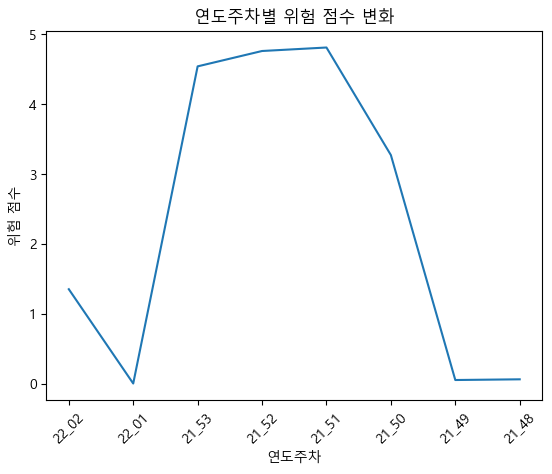

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
22_07주차
      연도주차     단가       신고중량
214  21_09 10.195  94605.349
215  21_10 10.037 119550.149
216  21_11 10.390 125476.449
217  21_12 10.453 146197.870
218  21_13 10.162 150753.546
219  21_14  9.852 140290.640
220  21_15  9.621 128867.112
221  21_16  9.196 114120.290
222  21_17  9.350 106992.423
223  21_18  9.638 101408.020
224  21_19 10.013 121817.874
225  21_20  9.977 125381.400
226  21_21 10.147 152749.953
227  21_22 10.167 164129.761
228  21_23  9.490 156312.136
229  21_24  9.620 155368.886
230  21_25  9.601 131997.200
231  21_26  9.705 147524.700
232  21_27 10.421 141420.950
233  21_28 10.462 16

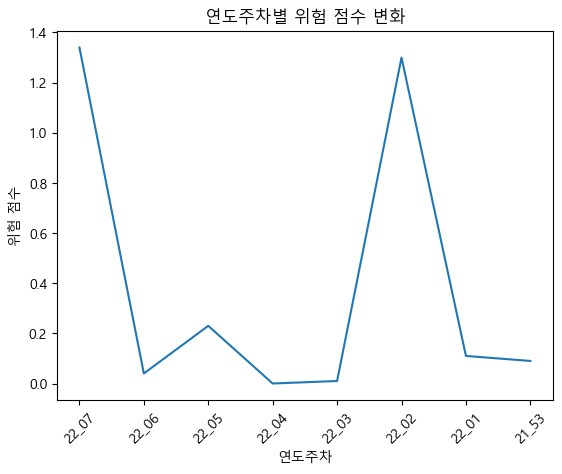

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
22_08주차
      연도주차     단가       신고중량
215  21_10  9.300 615575.662
216  21_11  9.672 615668.297
217  21_12  9.979 608740.494
218  21_13 10.184 627113.382
219  21_14 10.329 585409.915
220  21_15 10.529 590562.853
221  21_16 10.716 581756.949
222  21_17 10.961 566239.359
223  21_18 11.144 605266.935
224  21_19 11.442 607921.714
225  21_20 11.862 610291.216
226  21_21 12.057 587542.344
227  21_22 11.951 568714.768
228  21_23 11.591 554575.273
229  21_24 11.142 548016.885
230  21_25 10.882 551181.215
231  21_26 10.815 555615.528
232  21_27 10.860 545638.383
233  21_28 10.877 529042.071
234  21_29 10.978 52

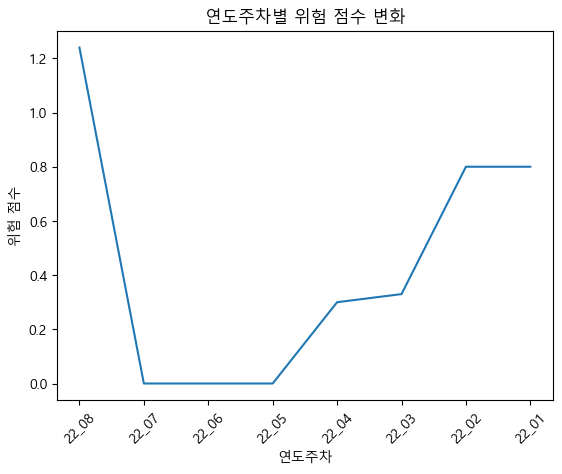

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
22_07주차
      연도주차    단가        신고중량
214  21_09 0.216  828835.000
215  21_10 0.217  717547.500
216  21_11 0.217  615187.500
217  21_12 0.217  411495.000
218  21_13 0.217  364135.000
219  21_14 0.216  267075.000
220  21_15 0.216  417842.500
221  21_16 0.216  604052.500
222  21_17 0.216  648885.000
223  21_18 0.223  808762.000
224  21_19 0.225  630552.000
225  21_20 0.227  520297.000
226  21_21 0.224  703284.500
227  21_22 0.216  697550.000
228  21_23 0.222  855198.250
229  21_24 0.222  934663.250
230  21_25 0.224  959354.500
231  21_26 0.226  805212.000
232  21_27 0.224  841536.250
233  21_28 0.231  8

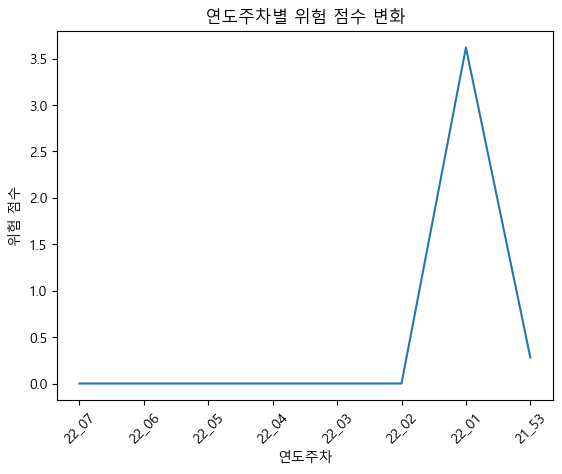

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
22_07주차
      연도주차    단가        신고중량
214  21_09 0.244  869097.500
215  21_10 0.239  683327.500
216  21_11 0.236  269977.500
217  21_12 0.247  164995.000
218  21_13 0.254  298164.750
219  21_14 0.254  298164.750
220  21_15 0.246  266651.000
221  21_16 0.256  235016.000
222  21_17 0.283  249818.000
223  21_18 0.283  249818.000
224  21_19 0.283  249814.250
225  21_20 0.282  376146.750
226  21_21 0.278  252635.000
227  21_22 0.272  380320.000
228  21_23 0.272  380320.000
229  21_24 0.269  357498.000
230  21_25 0.281  360203.750
231  21_26 0.293  232518.975
232  21_27 0.293  232518.975
233  21_28 0.287  1

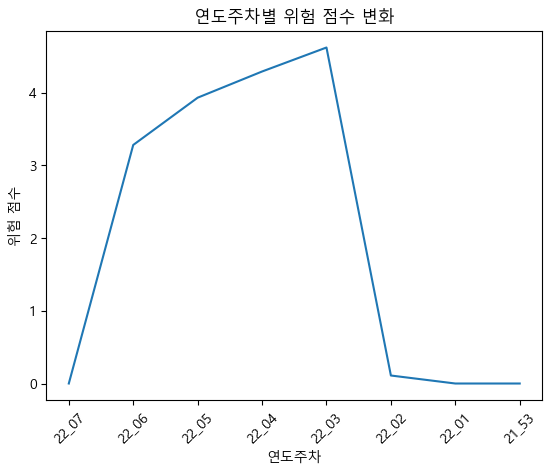

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
22_07주차
      연도주차    단가       신고중량
214  21_09 0.415 432751.167
215  21_10 0.410 475500.542
216  21_11 0.404 323250.542
217  21_12 0.412 405750.000
218  21_13 0.411 345500.125
219  21_14 0.414 364500.125
220  21_15 0.410 295501.375
221  21_16 0.424 255501.375
222  21_17 0.414 341751.250
223  21_18 0.418 467001.250
224  21_19 0.420 424251.000
225  21_20 0.408 394501.000
226  21_21 0.414 285251.000
227  21_22 0.407  98251.000
228  21_23 0.405 131500.000
229  21_24 0.392 213750.000
230  21_25 0.392 237500.000
231  21_26 0.392 266000.000
232  21_27 0.394 300750.000
233  21_28 0.394 262750.000
234  21_29 0.396 206000

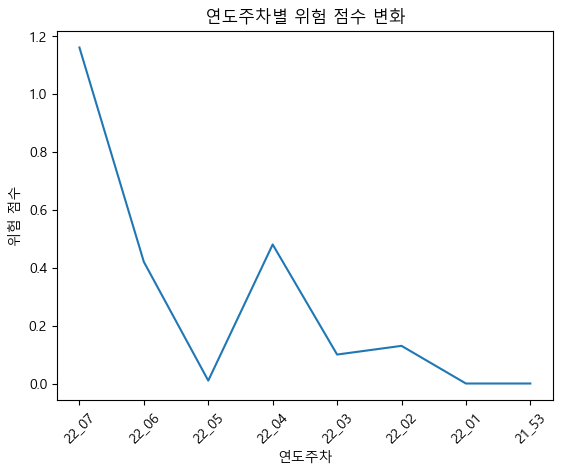

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
22_07주차
      연도주차    단가         신고중량
214  21_09 0.557 12704250.250
215  21_10 0.587  5539971.250
216  21_11 0.587  5569408.000
217  21_12 0.598   177156.750
218  21_13 0.633  1138045.250
219  21_14 0.647  7136791.200
220  21_15 0.646  8301232.700
221  21_16 0.642 11013298.730
222  21_17 0.633 14520791.730
223  21_18 0.622  8523733.280
224  21_19 0.633 11248927.030
225  21_20 0.634  8536861.000
226  21_21 0.663  3920911.075
227  21_22 0.658  4805742.575
228  21_23 0.527  3517106.575
229  21_24 0.571  4965419.825
230  21_25 0.570  4965268.250
231  21_26 0.559  4274324.250
232  21_27 0.679 

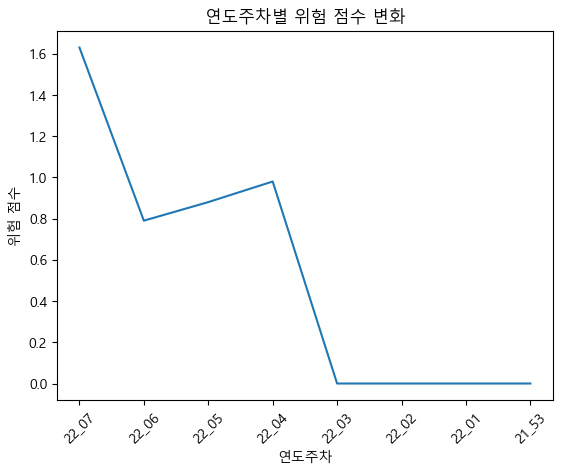

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
22_07주차
      연도주차    단가         신고중량
214  21_09 0.265 10848408.987
215  21_10 0.271 10939364.025
216  21_11 0.268 17474054.190
217  21_12 0.272  9429601.715
218  21_13 0.261 23952649.830
219  21_14 0.260 23754948.883
220  21_15 0.260 16850661.767
221  21_16 0.260 17458618.276
222  21_17 0.299  3554086.133
223  21_18 0.280 12218383.606
224  21_19 0.279 12107366.281
225  21_20 0.280 11516935.784
226  21_21 0.276 10898136.424
227  21_22 0.299  2380387.074
228  21_23 0.283 12491971.349
229  21_24 0.283 13279410.200
230  21_25 0.278 21462436.948
231  21_26 0.278 21448138.023
232  21_27 0.274 

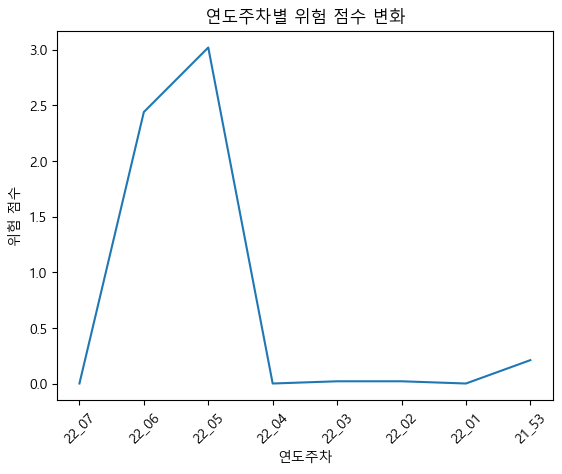

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
22_16주차
      연도주차    단가       신고중량
223  21_18 1.868 104593.403
224  21_19 1.884 103831.328
225  21_20 1.888 105693.828
226  21_21 1.972  74423.258
227  21_22 1.982  78403.830
228  21_23 2.164  91800.905
229  21_24 2.211  79802.405
230  21_25 2.363  68082.700
231  21_26 2.266  95649.625
232  21_27 2.237  88584.375
233  21_28 2.206 110632.875
234  21_29 2.106 104293.025
235  21_30 2.144 106678.025
236  21_31 2.074  75903.300
237  21_32 2.136  97053.180
238  21_33 2.217 122183.780
239  21_34 2.281  87141.280
240  21_35 2.268 103501.257
241  21_36 2.303  70622.625
242  21_37 2.208  58022.625
243  21_38 2.411  50237

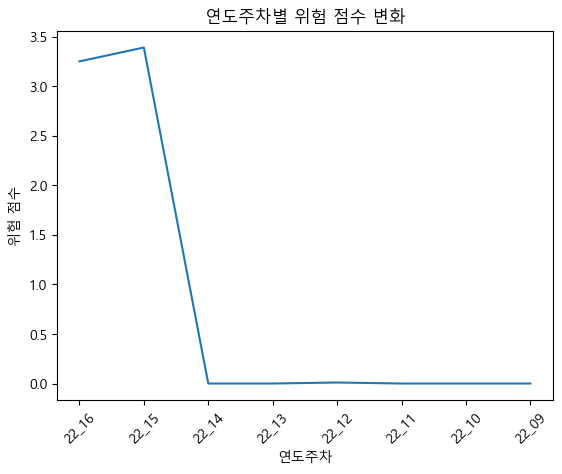

[np.float64(2.14), np.float64(0.91), np.float64(3.64), np.float64(1.84), np.float64(4.04), np.float64(4.31), np.float64(4.81), np.float64(1.34), np.float64(1.24), np.float64(3.62), np.float64(4.62), np.float64(1.16), np.float64(1.63), np.float64(3.02), np.float64(3.39)]
[54, 166, 82, 50, 45, 42, 40, 31, 30, 37, 35, 31, 31, 33, 23]


In [2]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        print(df_price_4w.iloc[p_eriod-l:-l])
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['단가'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['단가'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['단가'] - data_mean) / data_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

        #=================== 신고중량 percertile 구하기 ====================
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['신고중량'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['신고중량'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['신고중량'] - data_mean ) / data_std
        x=np.exp((scipy.stats.norm.cdf(abs(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y      
    
    
    if(z[j]>1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model1(1)'] = o
collect.loc[15, 'Model1(1)'] = np.sum(o)
collect.loc[:14, 'Model1(2)'] = z
collect.loc[15, 'Model1(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[2]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[2]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[2]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
      연도주차     단가        신고중량
203  20_51 12.129 1819475.697
204  20_52 11.984 1759198.849
205  20_53 12.347 1702628.788
206  21_01 11.683 1772732.696
207  21_02 12.158 1801110.265
208  21_03 12.330 1942272.072
209  21_04 12.285 2063378.412
210  21_05 12.515 2135877.091
211  21_06 13.271 1910684.931
212  21_07 13.807 1698594.161
213  21_08 14.311 1497006.522
214  21_09 15.821 1216500.177
215  21_10 14.435 1387471.016
216  21_11 13.925 1557317.076
217  21_12 13.304 1733684.614
218  21_13 12.550 1946767.614
219  21_14 12.274 2011353.845
220  21_15 11.901 2040727.035
221  21_16 11.674 2103305.349
222  21_17 11.701 2129829.188
223  21_18 11.671 2062311.091
224  21_19 11.323 2044849.603
225  21_20 11.439 1955011.476
226  21_21 11.235 1939171.723
227  21_22 11.117 1918588.422
228  21_23 11.300 1881981.178
229  21_24 11.127 1850456.215
230  21_25 11.482 1771389.791
231  21_26 12.033 1784857.980
232  21_27 12.253 1773956.662
233  21_28 12.344 1795661.931
234  21_29 

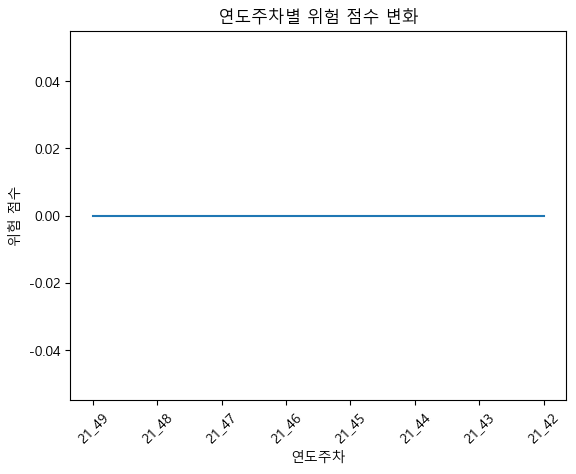

HS Code : 7326909000
21_49주차
      연도주차    단가         신고중량
203  20_51 3.834  9794627.961
204  20_52 3.985  9478324.210
205  20_53 4.133  9022161.538
206  21_01 4.049  9422341.837
207  21_02 4.178  8958114.316
208  21_03 4.165  9136034.447
209  21_04 4.174  9371354.125
210  21_05 4.239  9026954.088
211  21_06 4.336  8496187.737
212  21_07 4.360  8498653.435
213  21_08 4.582  7805880.210
214  21_09 4.783  7345828.460
215  21_10 4.699  7944217.924
216  21_11 4.419  8059489.703
217  21_12 4.331  9088337.616
218  21_13 4.257  9725865.154
219  21_14 4.197  9843348.104
220  21_15 4.334 10461909.664
221  21_16 4.160 10516870.233
222  21_17 4.222 10660959.379
223  21_18 4.080 10823314.582
224  21_19 4.029 10418023.225
225  21_20 4.205 10193539.467
226  21_21 4.097 10480084.041
227  21_22 4.330 10635030.073
228  21_23 4.476 10389724.092
229  21_24 4.382 10231758.284
230  21_25 4.371  9751462.372
231  21_26 4.282  9509626.703
232  21_27 4.434  9397969.806
233  21_28 4.414  9961440.152
234  21_29 

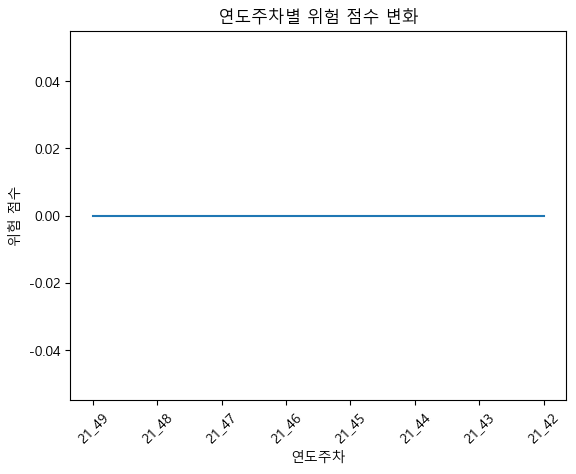

HS Code : 8708999000
21_49주차
      연도주차     단가        신고중량
203  20_51 14.864 1147660.053
204  20_52 14.780 1060236.535
205  20_53 14.506  997432.779
206  21_01 14.466 1080343.683
207  21_02 14.632 1058891.039
208  21_03 14.446 1151357.071
209  21_04 14.692 1199251.204
210  21_05 14.774 1138334.547
211  21_06 14.350 1048002.693
212  21_07 14.510 1046140.631
213  21_08 14.644  976627.393
214  21_09 15.057  894438.853
215  21_10 15.278 1077237.978
216  21_11 15.356 1113352.156
217  21_12 14.923 1229534.614
218  21_13 14.652 1307775.964
219  21_14 15.201 1180429.764
220  21_15 15.301 1155041.842
221  21_16 15.140 1090928.599
222  21_17 15.478 1038416.335
223  21_18 14.721 1024048.681
224  21_19 14.850  983070.550
225  21_20 15.336 1033698.270
226  21_21 14.648 1109445.525
227  21_22 14.531 1159773.967
228  21_23 14.007 1190345.384
229  21_24 13.881 1123803.251
230  21_25 14.143 1117668.599
231  21_26 14.621 1078423.856
232  21_27 14.497 1077162.885
233  21_28 14.400 1180097.572
234  21_29 

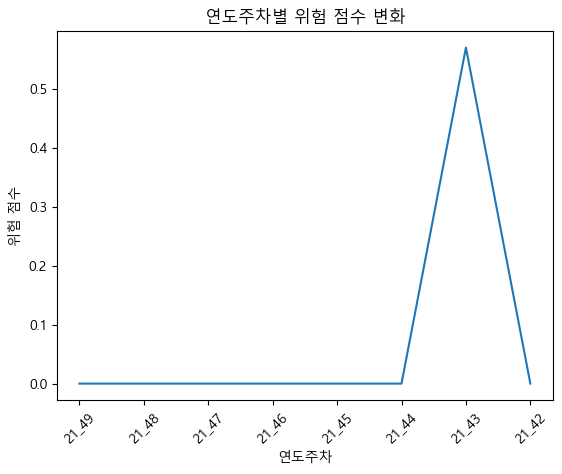

HS Code : 2106909099
21_49주차
      연도주차     단가        신고중량
203  20_51 30.593 1390671.633
204  20_52 28.459 1425981.735
205  20_53 27.590 1350678.512
206  21_01 24.369 1474688.966
207  21_02 24.924 1415681.133
208  21_03 26.267 1364841.412
209  21_04 26.436 1553107.167
210  21_05 27.241 1534554.360
211  21_06 25.988 1459785.140
212  21_07 26.008 1534417.363
213  21_08 25.668 1539912.319
214  21_09 27.228 1468109.150
215  21_10 26.945 1723540.423
216  21_11 26.874 1785415.611
217  21_12 25.740 1841932.449
218  21_13 23.675 1937097.027
219  21_14 23.194 1890610.736
220  21_15 22.879 1756093.744
221  21_16 22.957 1789778.667
222  21_17 24.092 1698466.847
223  21_18 25.188 1631714.081
224  21_19 24.300 1780501.389
225  21_20 26.033 1644895.390
226  21_21 25.691 1761011.467
227  21_22 23.988 1949838.122
228  21_23 23.960 1890891.464
229  21_24 22.640 1958184.733
230  21_25 22.399 1906565.297
231  21_26 23.656 1772892.223
232  21_27 22.847 1808104.031
233  21_28 22.755 1807024.343
234  21_29 

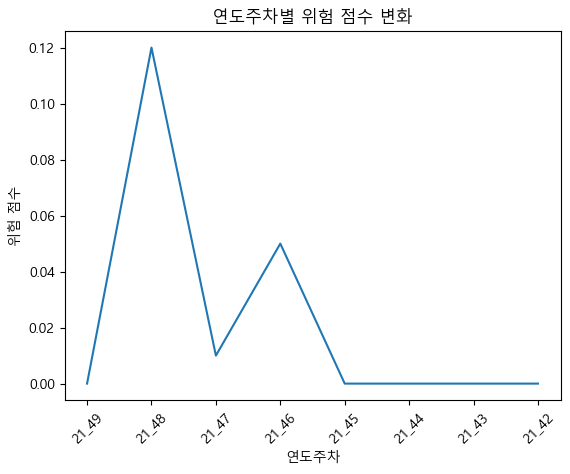

HS Code : 4911990000
21_49주차
      연도주차     단가      신고중량
203  20_51 31.889 31987.349
204  20_52 26.694 31920.607
205  20_53 20.066 31671.601
206  21_01 27.773 34234.887
207  21_02 28.758 31260.776
208  21_03 34.575 34954.207
209  21_04 28.508 47627.303
210  21_05 19.205 50995.766
211  21_06 20.105 45683.273
212  21_07 15.976 39107.184
213  21_08 18.177 35738.056
214  21_09 36.025 31846.155
215  21_10 46.020 30913.891
216  21_11 38.914 38750.404
217  21_12 44.076 34721.116
218  21_13 32.960 35188.926
219  21_14 25.394 37032.027
220  21_15 37.994 33044.941
221  21_16 28.626 42030.655
222  21_17 36.832 45695.521
223  21_18 37.516 42908.317
224  21_19 31.605 42501.615
225  21_20 36.665 34417.483
226  21_21 22.455 42464.689
227  21_22 29.634 43555.230
228  21_23 26.087 44156.331
229  21_24 26.901 42523.815
230  21_25 45.386 36675.460
231  21_26 49.568 36301.648
232  21_27 56.153 37859.513
233  21_28 65.112 39021.552
234  21_29 77.807 32634.367
235  21_30 70.767 33512.701
236  21_31 68.448 3

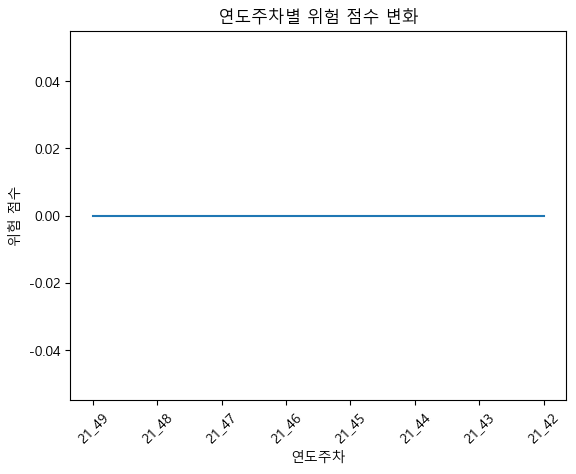

HS Code : 6403999000
21_49주차
      연도주차     단가       신고중량
203  20_51 56.651 198311.164
204  20_52 57.430 175366.949
205  20_53 61.704 152396.321
206  21_01 59.156 170796.983
207  21_02 58.785 167876.837
208  21_03 56.215 188928.668
209  21_04 55.136 211172.313
210  21_05 53.046 228826.520
211  21_06 53.916 226487.680
212  21_07 55.969 223980.398
213  21_08 60.142 192257.358
214  21_09 69.866 149261.509
215  21_10 73.783 152139.095
216  21_11 73.991 156269.393
217  21_12 68.629 187880.168
218  21_13 66.752 200660.488
219  21_14 64.875 205405.231
220  21_15 64.729 189411.643
221  21_16 65.305 176598.295
222  21_17 60.903 179478.138
223  21_18 61.623 176979.336
224  21_19 57.752 194145.809
225  21_20 54.839 205295.028
226  21_21 57.454 195456.959
227  21_22 53.092 212772.457
228  21_23 53.606 217841.734
229  21_24 54.857 218682.024
230  21_25 54.729 223989.285
231  21_26 57.214 199180.026
232  21_27 60.208 188918.611
233  21_28 61.342 179352.688
234  21_29 62.758 182767.727
235  21_30 61.

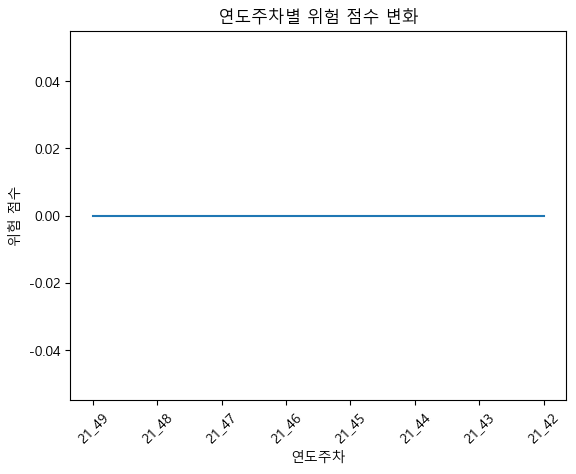

HS Code : 9031809099
21_49주차
      연도주차      단가       신고중량
203  20_51 118.813 159405.718
204  20_52 130.360 141906.169
205  20_53 144.109 123214.065
206  21_01 139.926 126757.859
207  21_02 131.068 128244.977
208  21_03 120.233 140214.064
209  21_04 110.134 155771.288
210  21_05 113.228 151962.699
211  21_06 116.638 137154.806
212  21_07 119.542 130821.274
213  21_08 126.038 129683.456
214  21_09 172.230 110399.881
215  21_10 168.641 125451.235
216  21_11 158.830 141869.405
217  21_12 162.813 143993.436
218  21_13 127.183 157473.529
219  21_14 138.774 154579.937
220  21_15 132.574 156843.965
221  21_16  99.811 197484.775
222  21_17  99.872 195251.764
223  21_18  90.912 196854.655
224  21_19  96.972 188420.641
225  21_20 130.949 142856.363
226  21_21 141.057 137485.545
227  21_22 132.804 154333.737
228  21_23 137.055 143744.136
229  21_24 134.151 152436.631
230  21_25 119.467 171015.941
231  21_26 110.096 185553.374
232  21_27 104.505 197324.026
233  21_28 116.429 197407.913
234  21_29 

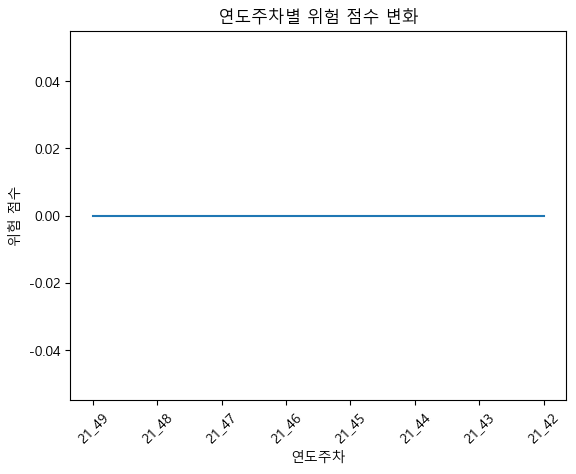

HS Code : 8542391000
21_49주차
      연도주차       단가      신고중량
203  20_51 2256.886 63850.649
204  20_52 2242.619 60700.283
205  20_53 2305.941 54490.840
206  21_01 2781.164 53577.814
207  21_02 2807.971 53873.643
208  21_03 2761.921 58031.125
209  21_04 2718.783 63704.304
210  21_05 2557.276 64717.662
211  21_06 2552.681 61313.521
212  21_07 2749.718 56214.816
213  21_08 2780.115 57786.492
214  21_09 2647.720 56139.240
215  21_10 2629.516 60781.844
216  21_11 2468.133 65919.997
217  21_12 2385.607 65911.369
218  21_13 2466.182 68338.959
219  21_14 2613.486 66497.641
220  21_15 2703.610 69192.029
221  21_16 2658.496 68168.037
222  21_17 2801.852 68613.718
223  21_18 2832.313 69126.845
224  21_19 2719.244 66327.720
225  21_20 2886.005 66368.793
226  21_21 3027.613 66461.467
227  21_22 2898.081 70040.871
228  21_23 2923.625 69350.386
229  21_24 2872.304 67404.706
230  21_25 2555.152 66710.575
231  21_26 2636.451 64802.143
232  21_27 2869.053 65727.213
233  21_28 2860.062 67994.939
234  21_29 

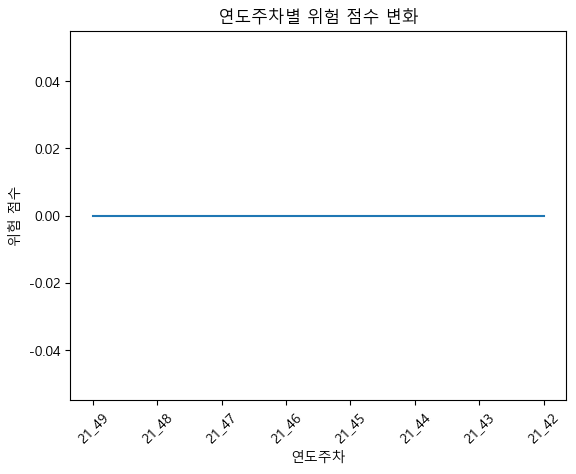

HS Code : 6109101000
21_49주차
      연도주차     단가       신고중량
203  20_51 23.925 236235.962
204  20_52 25.071 249461.332
205  20_53 26.246 257769.357
206  21_01 25.052 347943.414
207  21_02 24.693 374962.800
208  21_03 24.251 440008.921
209  21_04 23.896 492790.831
210  21_05 24.105 496272.931
211  21_06 24.540 502448.792
212  21_07 24.040 556054.944
213  21_08 23.204 618732.455
214  21_09 23.723 604435.674
215  21_10 23.581 665011.716
216  21_11 22.758 712068.731
217  21_12 22.995 715810.698
218  21_13 21.824 872650.426
219  21_14 20.911 939812.717
220  21_15 21.489 928789.693
221  21_16 21.456 948204.910
222  21_17 21.403 882514.715
223  21_18 21.996 807553.246
224  21_19 21.933 742778.464
225  21_20 22.313 693137.735
226  21_21 22.951 616960.170
227  21_22 22.849 598763.631
228  21_23 22.531 618013.041
229  21_24 22.500 578206.952
230  21_25 23.974 516612.442
231  21_26 24.004 477899.593
232  21_27 24.344 433605.195
233  21_28 24.130 414416.509
234  21_29 24.132 416730.944
235  21_30 24.

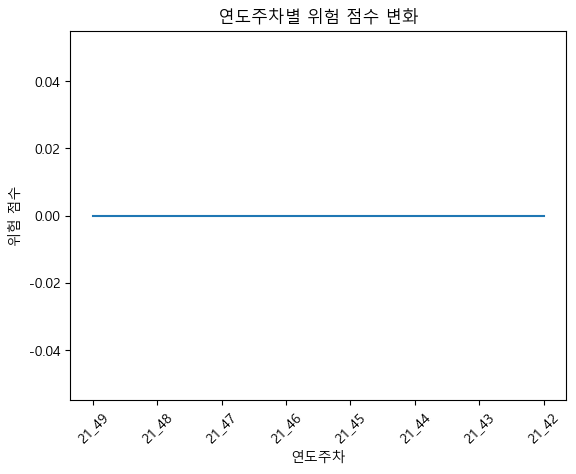

HS Code : 2934996000
21_49주차
      연도주차      단가      신고중량
203  20_51  28.606 18821.383
204  20_52  27.447 18862.281
205  20_53  13.863 15048.863
206  21_01  11.236 18815.891
207  21_02  22.536  7939.427
208  21_03  23.756  7909.596
209  21_04  25.531  7988.876
210  21_05  11.229 24979.876
211  21_06   9.159 25106.271
212  21_07   8.996 28840.466
213  21_08   8.717 35379.893
214  21_09  22.087 14619.165
215  21_10  33.561 10737.063
216  21_11  31.723 11520.767
217  21_12  25.376 16077.730
218  21_13  16.853 19829.516
219  21_14  15.676 22395.917
220  21_15  18.773 17856.616
221  21_16  16.361 24042.410
222  21_17  15.949 24064.265
223  21_18  17.563 22490.047
224  21_19  13.767 33740.466
225  21_20  17.856 20222.153
226  21_21  19.525 19011.696
227  21_22  14.938 19208.707
228  21_23  11.916 23707.086
229  21_24  11.108 23735.447
230  21_25  10.050 25083.470
231  21_26  11.546 23931.782
232  21_27  24.292  8168.822
233  21_28  15.135 16122.345
234  21_29  20.345 13146.499
235  21_30  20

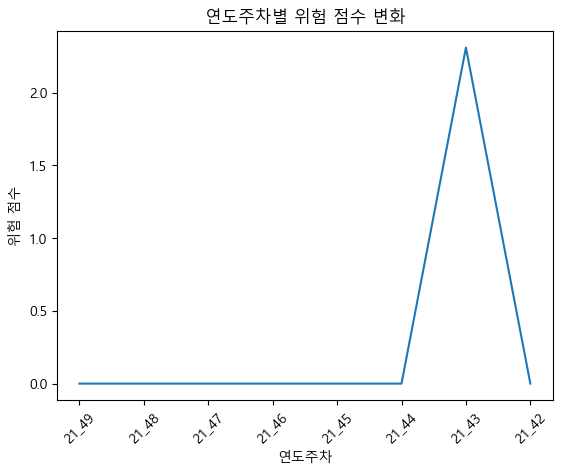

HS Code : 4016930000
21_49주차
      연도주차     단가       신고중량
203  20_51 34.964 100267.242
204  20_52 36.334  99946.791
205  20_53 36.767  97372.175
206  21_01 38.210  92455.967
207  21_02 38.089  94689.610
208  21_03 36.646  98809.827
209  21_04 39.592 104727.600
210  21_05 38.335 118160.091
211  21_06 36.446 112979.570
212  21_07 40.501  99891.753
213  21_08 40.052  92513.230
214  21_09 45.578  78766.203
215  21_10 49.965  80476.561
216  21_11 50.065  86805.219
217  21_12 46.072  93231.855
218  21_13 42.161  97816.822
219  21_14 43.278  94632.125
220  21_15 42.829  91410.564
221  21_16 45.216  83980.870
222  21_17 44.219  92772.956
223  21_18 44.366  91332.883
224  21_19 41.591  98136.791
225  21_20 42.556  97795.592
226  21_21 44.247  84961.463
227  21_22 41.460  88424.403
228  21_23 41.786  87811.152
229  21_24 40.328  92481.733
230  21_25 39.917  93346.291
231  21_26 38.604  96319.930
232  21_27 38.424  89162.166
233  21_28 41.718  89937.742
234  21_29 41.623  92982.405
235  21_30 43.

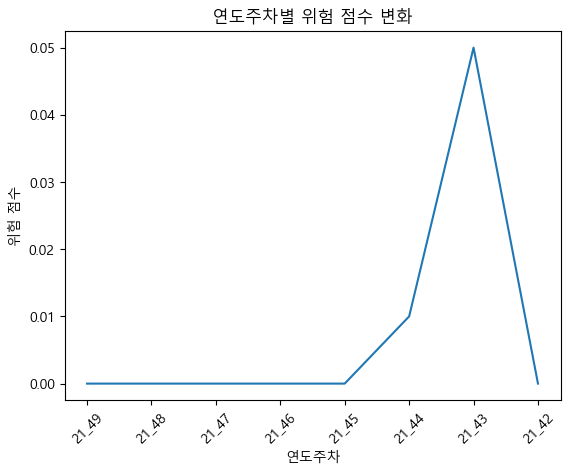

HS Code : 6110200000
21_49주차
      연도주차     단가       신고중량
203  20_51 29.242 299498.548
204  20_52 31.971 275640.367
205  20_53 29.360 297390.431
206  21_01 28.236 345911.408
207  21_02 27.051 363089.810
208  21_03 26.557 410319.862
209  21_04 26.970 437522.196
210  21_05 28.380 399271.177
211  21_06 30.147 377510.736
212  21_07 31.425 348515.607
213  21_08 34.940 285424.524
214  21_09 39.486 224653.800
215  21_10 40.695 196720.530
216  21_11 41.860 171201.544
217  21_12 43.280 151640.493
218  21_13 40.787 150454.720
219  21_14 43.373 127296.838
220  21_15 45.237 113382.112
221  21_16 47.186 106552.030
222  21_17 53.835  88683.924
223  21_18 56.008  78035.576
224  21_19 59.799  71602.144
225  21_20 57.506  76149.564
226  21_21 59.377  73984.084
227  21_22 58.055  82991.325
228  21_23 51.578  98366.740
229  21_24 52.098  93972.626
230  21_25 48.919 113234.487
231  21_26 42.901 150542.702
232  21_27 43.594 167251.436
233  21_28 38.884 218450.401
234  21_29 36.076 257252.360
235  21_30 32.

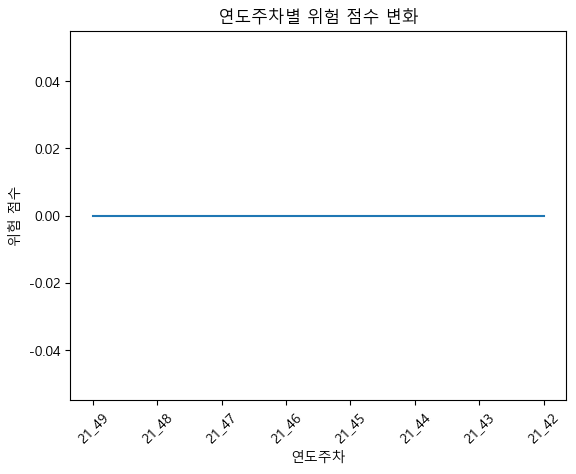

HS Code : 6211499000
21_49주차
      연도주차      단가      신고중량
203  20_51  96.327 26930.459
204  20_52 102.811 24421.996
205  20_53  85.643 25027.774
206  21_01  87.263 21604.538
207  21_02  79.523 22161.393
208  21_03  78.595 22568.227
209  21_04  73.966 26826.899
210  21_05  69.008 28972.130
211  21_06  70.526 25455.630
212  21_07  63.778 27769.148
213  21_08  80.995 21867.247
214  21_09  96.713 18280.738
215  21_10 101.430 19556.000
216  21_11 110.217 18692.384
217  21_12 102.788 20379.634
218  21_13  87.171 24753.296
219  21_14  82.433 25092.587
220  21_15  80.998 25113.794
221  21_16  71.119 26347.047
222  21_17  75.749 23875.302
223  21_18  73.745 25154.702
224  21_19  67.025 26195.039
225  21_20  69.800 24931.866
226  21_21  62.408 26747.747
227  21_22  57.960 27421.702
228  21_23  56.332 26681.170
229  21_24  55.327 25954.544
230  21_25  59.201 24207.117
231  21_26  60.941 24995.344
232  21_27  67.440 23005.472
233  21_28  66.584 26285.071
234  21_29  67.730 27927.277
235  21_30  67

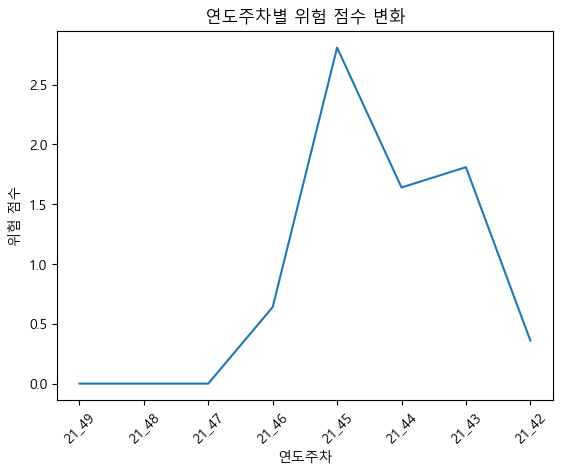

HS Code : 4202999000
21_49주차
      연도주차     단가      신고중량
203  20_51 34.122 66723.245
204  20_52 34.382 67152.349
205  20_53 34.261 61066.964
206  21_01 35.999 55428.709
207  21_02 34.259 55706.149
208  21_03 30.404 63913.987
209  21_04 30.961 68270.610
210  21_05 32.569 69112.077
211  21_06 33.650 62976.340
212  21_07 45.540 47304.053
213  21_08 54.492 39131.426
214  21_09 63.134 31463.999
215  21_10 66.367 32201.121
216  21_11 49.232 43691.699
217  21_12 42.242 53012.843
218  21_13 38.988 59486.694
219  21_14 35.145 65225.049
220  21_15 37.519 61583.547
221  21_16 41.410 55881.757
222  21_17 42.431 57716.022
223  21_18 41.669 59666.627
224  21_19 41.410 58611.340
225  21_20 39.800 59282.937
226  21_21 35.176 63785.790
227  21_22 38.123 59075.356
228  21_23 35.823 62289.757
229  21_24 37.131 60217.443
230  21_25 44.852 50010.755
231  21_26 44.968 49202.336
232  21_27 45.023 49535.937
233  21_28 42.262 53348.804
234  21_29 41.153 52855.733
235  21_30 36.810 58966.901
236  21_31 41.165 5

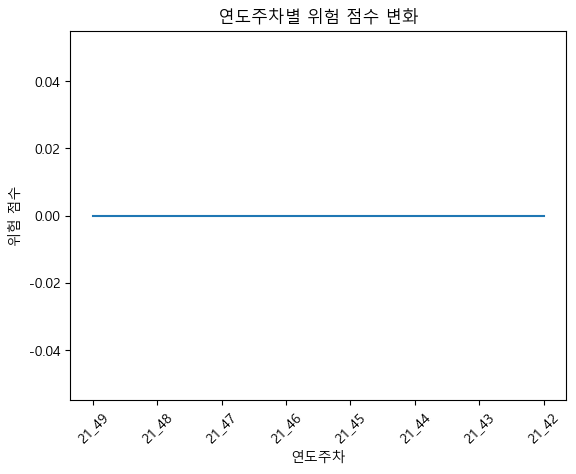

HS Code : 3304991000
21_49주차
      연도주차      단가       신고중량
203  20_51  86.209 895898.917
204  20_52  90.662 863778.879
205  20_53  87.106 773564.771
206  21_01  83.125 737856.007
207  21_02  89.438 693434.264
208  21_03  84.440 648984.694
209  21_04  90.622 752263.109
210  21_05  97.621 762292.448
211  21_06 101.033 712792.733
212  21_07 103.631 707502.222
213  21_08 102.218 791944.354
214  21_09 100.352 851615.701
215  21_10  92.587 946542.836
216  21_11  89.308 911068.268
217  21_12  87.586 788309.735
218  21_13  86.982 678862.908
219  21_14  90.305 609830.681
220  21_15  91.645 614372.756
221  21_16  88.063 657510.563
222  21_17  87.028 616650.975
223  21_18  97.857 710133.699
224  21_19 100.398 812113.305
225  21_20 105.771 791814.180
226  21_21 101.253 822443.864
227  21_22  93.449 684679.278
228  21_23 102.502 594627.936
229  21_24  89.798 633933.438
230  21_25 100.392 800177.722
231  21_26  93.211 853352.563
232  21_27  92.208 938352.973
233  21_28 102.791 961776.628
234  21_29 

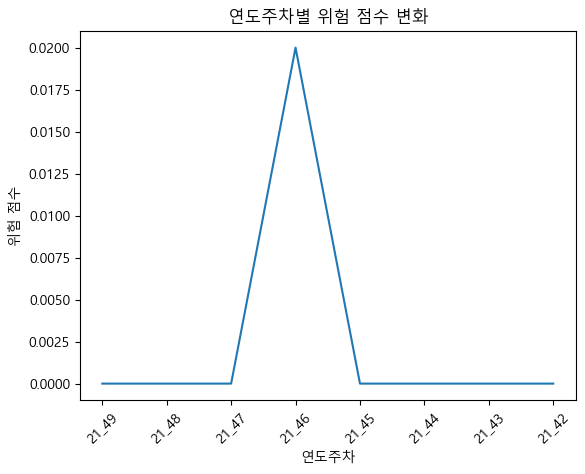

HS Code : 8544429090
21_49주차
      연도주차     단가       신고중량
203  20_51 33.005 101156.466
204  20_52 32.264 104575.839
205  20_53 32.498  90694.047
206  21_01 31.718  91340.301
207  21_02 30.811  97390.501
208  21_03 31.764  93108.943
209  21_04 31.790 108288.520
210  21_05 31.511 114102.541
211  21_06 30.684 107743.333
212  21_07 29.947 110252.016
213  21_08 31.312  94104.531
214  21_09 40.186  73504.044
215  21_10 44.108  70308.645
216  21_11 46.488  72606.482
217  21_12 38.744  96151.522
218  21_13 33.197 106836.255
219  21_14 30.249 119633.426
220  21_15 26.857 134854.356
221  21_16 27.152 133557.645
222  21_17 27.316 138059.527
223  21_18 28.151 139239.920
224  21_19 31.244 121560.253
225  21_20 31.697 113327.270
226  21_21 30.831 114838.293
227  21_22 29.622 128562.463
228  21_23 30.586 127314.430
229  21_24 28.875 137821.567
230  21_25 29.252 136035.254
231  21_26 30.389 121862.583
232  21_27 28.860 129366.433
233  21_28 30.077 129812.106
234  21_29 29.858 127527.540
235  21_30 29.

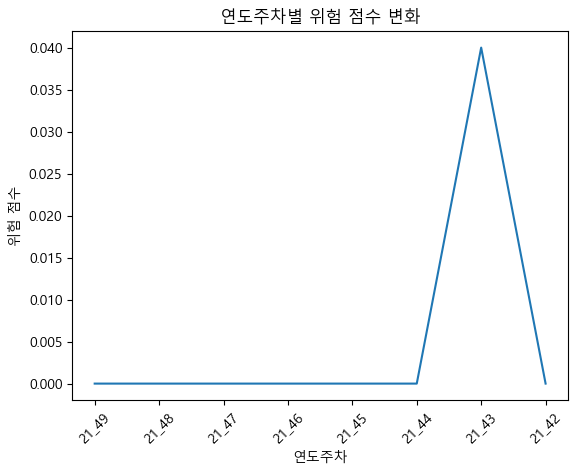

HS Code : 8481801090
21_49주차
      연도주차     단가       신고중량
203  20_51 25.851 745657.387
204  20_52 26.282 735916.234
205  20_53 27.341 656786.258
206  21_01 25.815 626885.485
207  21_02 25.447 699180.763
208  21_03 25.375 718567.250
209  21_04 24.835 860693.386
210  21_05 26.846 905105.367
211  21_06 27.876 816191.459
212  21_07 26.938 853771.850
213  21_08 29.803 731216.577
214  21_09 29.993 686092.307
215  21_10 31.451 675586.253
216  21_11 34.726 616090.162
217  21_12 27.255 744523.519
218  21_13 26.708 775825.052
219  21_14 24.905 853465.530
220  21_15 24.714 856390.379
221  21_16 27.729 782330.475
222  21_17 27.359 790164.627
223  21_18 27.358 768365.829
224  21_19 24.365 869983.630
225  21_20 23.351 885629.355
226  21_21 23.010 955128.728
227  21_22 22.514 960218.899
228  21_23 24.061 910728.845
229  21_24 24.182 939013.289
230  21_25 25.071 902560.562
231  21_26 28.037 833864.725
232  21_27 26.870 829148.369
233  21_28 29.777 757008.066
234  21_29 29.891 715641.028
235  21_30 27.

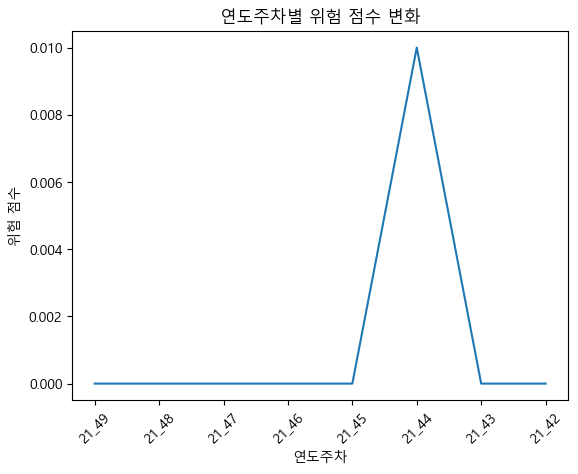

HS Code : 3304999000
21_49주차
      연도주차      단가      신고중량
203  20_51  90.809 69085.617
204  20_52  93.545 69945.386
205  20_53  88.786 63323.314
206  21_01  83.044 55280.012
207  21_02  80.828 58239.447
208  21_03  78.896 65541.687
209  21_04  92.117 77103.102
210  21_05  92.729 83607.440
211  21_06  91.215 76749.692
212  21_07  90.842 78091.016
213  21_08  82.403 72623.321
214  21_09  78.346 66754.132
215  21_10  76.600 68426.881
216  21_11  77.672 72709.815
217  21_12  75.443 66355.998
218  21_13  74.243 65671.971
219  21_14  71.886 61989.013
220  21_15  73.915 57669.616
221  21_16  78.705 66968.734
222  21_17  79.987 69269.887
223  21_18  82.923 67478.111
224  21_19  81.802 68916.611
225  21_20  76.558 65299.890
226  21_21  85.536 63595.200
227  21_22  87.232 65044.903
228  21_23  88.889 61328.417
229  21_24  93.692 56158.347
230  21_25  88.415 61009.977
231  21_26  83.085 59997.862
232  21_27  83.627 55924.739
233  21_28  80.657 60633.841
234  21_29  82.861 54774.001
235  21_30  87

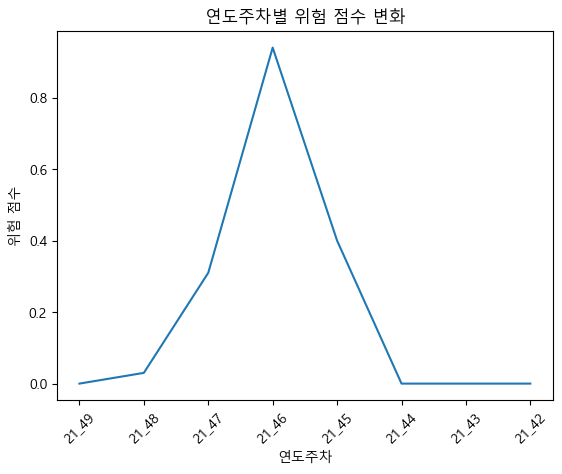

HS Code : 8543709090
21_49주차
      연도주차      단가       신고중량
203  20_51 185.806 114901.258
204  20_52 175.138 123705.927
205  20_53 187.684 118801.859
206  21_01 180.225 117365.541
207  21_02 187.441 114685.115
208  21_03 214.822 105548.869
209  21_04 206.267 107293.353
210  21_05 200.597 111569.125
211  21_06 193.947 103047.654
212  21_07 171.738 108044.975
213  21_08 168.679 111914.667
214  21_09 174.741 113309.133
215  21_10 213.336 126381.161
216  21_11 226.724 121721.579
217  21_12 242.045 118515.808
218  21_13 248.765 115308.265
219  21_14 198.314 125048.361
220  21_15 169.820 146069.620
221  21_16 168.075 160046.076
222  21_17 166.659 177543.913
223  21_18 156.142 191165.981
224  21_19 159.779 194055.995
225  21_20 142.664 201794.345
226  21_21 130.261 204975.944
227  21_22 121.516 217648.304
228  21_23 120.152 220474.764
229  21_24 110.349 239269.731
230  21_25 110.439 233514.368
231  21_26 112.164 224155.764
232  21_27 106.178 222957.758
233  21_28 109.278 203619.436
234  21_29 

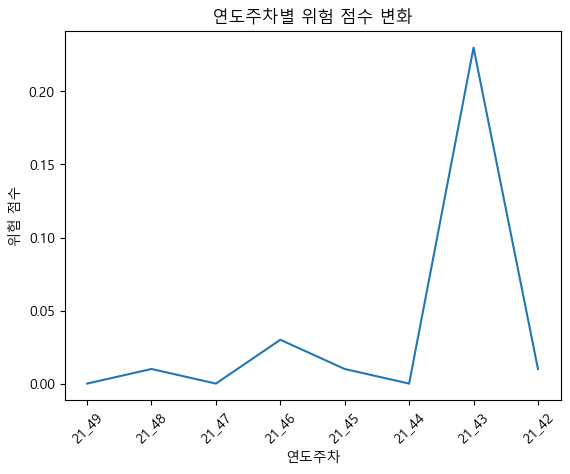

HS Code : 6404199000
21_49주차
      연도주차     단가       신고중량
203  20_51 26.107 520404.531
204  20_52 26.332 480924.053
205  20_53 27.300 447449.153
206  21_01 27.052 430692.927
207  21_02 27.120 420553.085
208  21_03 26.879 465878.654
209  21_04 26.282 515497.552
210  21_05 24.838 626515.750
211  21_06 25.147 610039.417
212  21_07 26.510 646050.059
213  21_08 26.764 621615.471
214  21_09 29.931 453071.774
215  21_10 29.733 451326.013
216  21_11 28.611 419521.646
217  21_12 27.297 458434.889
218  21_13 26.070 513141.071
219  21_14 25.384 531603.020
220  21_15 23.329 565620.770
221  21_16 22.967 567039.904
222  21_17 22.176 593108.625
223  21_18 21.762 586081.361
224  21_19 22.408 580144.762
225  21_20 23.019 526949.444
226  21_21 23.241 522894.222
227  21_22 24.135 532576.828
228  21_23 25.168 488479.528
229  21_24 26.675 470996.684
230  21_25 26.259 445754.218
231  21_26 25.973 452429.346
232  21_27 26.258 416223.727
233  21_28 25.590 439234.867
234  21_29 27.248 415301.195
235  21_30 27.

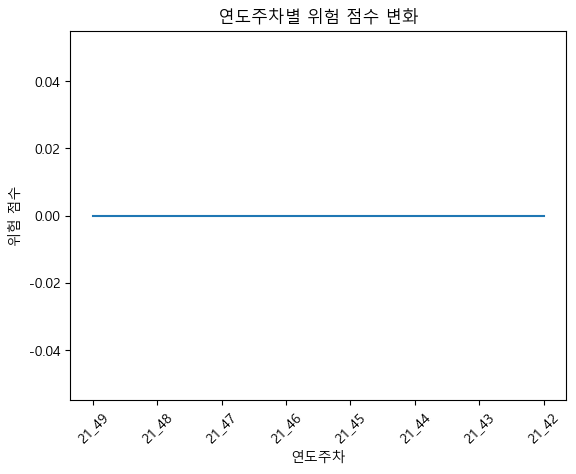

HS Code : 3004909900
21_49주차
      연도주차     단가        신고중량
203  20_51 72.796  949155.776
204  20_52 72.107  884812.030
205  20_53 57.935  927750.900
206  21_01 42.160 1065655.376
207  21_02 43.867 1027494.291
208  21_03 50.219  998972.053
209  21_04 53.415 1128644.685
210  21_05 57.702 1067489.233
211  21_06 59.048  972902.547
212  21_07 63.257 1012630.833
213  21_08 60.350 1050135.055
214  21_09 62.814 1043717.554
215  21_10 64.728 1190000.295
216  21_11 51.076 1397844.594
217  21_12 58.894 1247817.151
218  21_13 52.509 1270493.676
219  21_14 47.063 1277965.616
220  21_15 59.577 1055536.420
221  21_16 55.215 1051105.706
222  21_17 58.703 1004817.653
223  21_18 66.742  900701.415
224  21_19 55.482 1127843.845
225  21_20 62.488 1198294.538
226  21_21 61.766 1249240.160
227  21_22 57.237 1242657.547
228  21_23 59.045 1115945.667
229  21_24 55.729  968106.127
230  21_25 52.862 1046822.982
231  21_26 56.255 1095854.790
232  21_27 63.097 1043910.511
233  21_28 61.379 1085118.332
234  21_29 

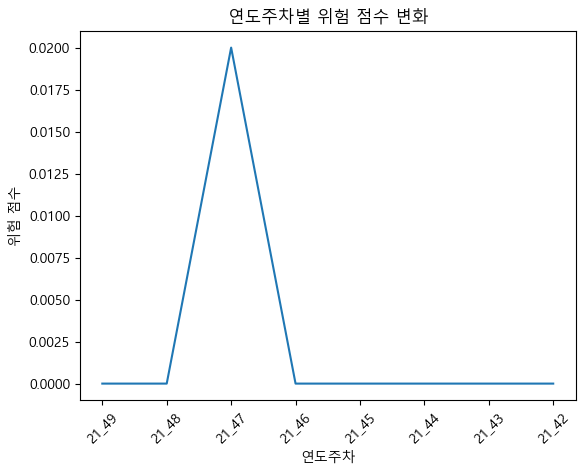

HS Code : 8542311000
21_49주차
      연도주차       단가      신고중량
203  20_51 5897.716 64384.203
204  20_52 5861.924 62173.378
205  20_53 5773.649 57198.122
206  21_01 5821.261 61487.767
207  21_02 5857.884 61511.488
208  21_03 6034.880 65438.606
209  21_04 5998.963 70028.356
210  21_05 6075.663 68452.137
211  21_06 6039.670 64407.045
212  21_07 6257.799 61374.746
213  21_08 5971.406 65206.844
214  21_09 5941.204 63760.082
215  21_10 5860.112 67543.976
216  21_11 5708.886 68729.274
217  21_12 5810.848 65637.259
218  21_13 6049.501 66427.610
219  21_14 7027.921 67031.380
220  21_15 6761.460 67588.560
221  21_16 6853.300 69169.640
222  21_17 7193.001 69432.934
223  21_18 7027.247 69572.576
224  21_19 6992.967 71266.783
225  21_20 7330.021 69456.767
226  21_21 6594.990 69431.319
227  21_22 6515.657 71243.606
228  21_23 7125.140 71328.368
229  21_24 6957.356 72416.649
230  21_25 7681.144 74970.085
231  21_26 7616.440 73745.767
232  21_27 7337.001 73840.328
233  21_28 7427.584 76541.100
234  21_29 

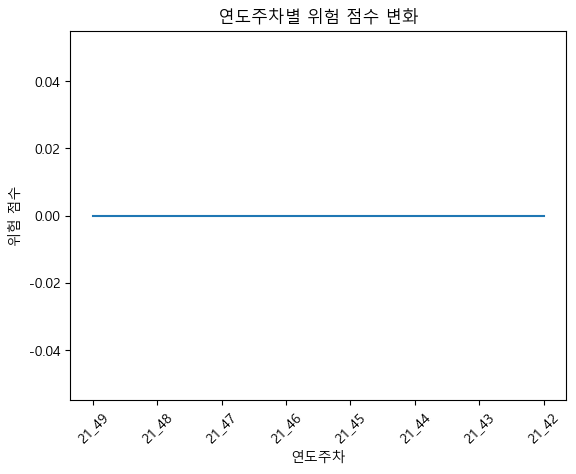

HS Code : 4901999000
21_49주차
      연도주차     단가       신고중량
203  20_51 17.773 156112.714
204  20_52 18.268 146759.967
205  20_53 18.230 145173.954
206  21_01 16.762 162615.894
207  21_02 18.023 131172.290
208  21_03 17.131 144767.654
209  21_04 19.855 145953.964
210  21_05 19.629 147626.903
211  21_06 20.078 138382.624
212  21_07 20.758 131102.591
213  21_08 18.398 144898.737
214  21_09 19.621 128096.758
215  21_10 18.932 146242.413
216  21_11 18.715 149179.005
217  21_12 18.463 146818.156
218  21_13 17.863 146186.027
219  21_14 18.134 131721.284
220  21_15 17.406 122242.320
221  21_16 18.422 103508.030
222  21_17 19.333  99488.739
223  21_18 17.770 113927.592
224  21_19 18.294 118790.850
225  21_20 18.096 127594.879
226  21_21 17.033 138000.539
227  21_22 18.093 125582.861
228  21_23 18.971 109948.093
229  21_24 18.037 110078.550
230  21_25 19.325 112299.863
231  21_26 19.567 108977.843
232  21_27 19.201 126470.397
233  21_28 20.917 122653.449
234  21_29 20.649 115024.460
235  21_30 20.

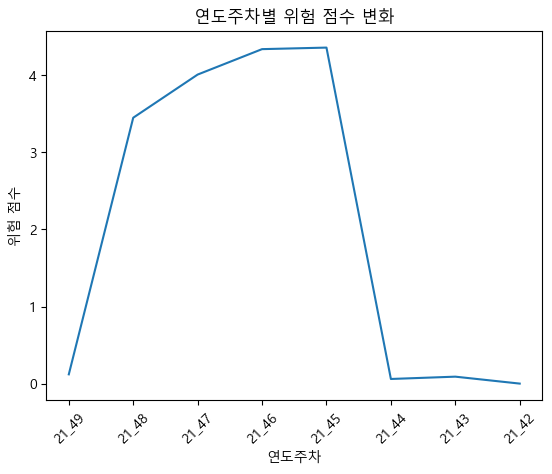

HS Code : 8473309090
21_49주차
      연도주차      단가       신고중량
203  20_51 116.975  91610.984
204  20_52 119.995  92051.675
205  20_53 129.909  77842.865
206  21_01 128.393  86542.998
207  21_02 113.742 100110.152
208  21_03 109.996 101947.967
209  21_04 107.696 117595.562
210  21_05 105.213 116982.294
211  21_06 108.393 107676.617
212  21_07 124.189 101035.314
213  21_08 149.396  97998.599
214  21_09 156.130  88765.762
215  21_10 161.192  92721.788
216  21_11 179.458  94079.364
217  21_12 158.973  91236.670
218  21_13 151.916  91985.670
219  21_14 160.053 100437.050
220  21_15 135.055  96740.772
221  21_16 123.243 103494.308
222  21_17 126.628 110084.233
223  21_18 103.421 112279.497
224  21_19 102.523 125013.417
225  21_20 104.975 129312.819
226  21_21 101.953 120107.387
227  21_22 125.612 117170.698
228  21_23 125.336 104144.267
229  21_24 132.466 107118.506
230  21_25 136.789 105750.325
231  21_26 149.625  97224.462
232  21_27 157.319 109545.895
233  21_28 167.218  89423.803
234  21_29 

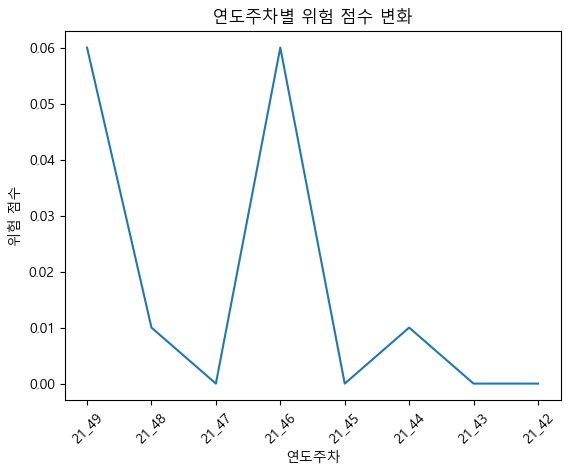

HS Code : 6307909000
21_49주차
      연도주차     단가       신고중량
203  20_51  9.547 900164.355
204  20_52  9.611 855200.547
205  20_53  9.595 860998.015
206  21_01  9.457 834873.097
207  21_02  9.841 807575.211
208  21_03  9.571 835761.196
209  21_04  9.180 827035.271
210  21_05  8.332 833551.007
211  21_06  7.836 757710.825
212  21_07  8.226 636615.410
213  21_08  8.828 526757.970
214  21_09  9.895 412525.561
215  21_10 10.217 418786.510
216  21_11  9.504 463819.705
217  21_12  8.929 550360.442
218  21_13  8.419 642785.004
219  21_14  8.443 686437.830
220  21_15  8.362 743660.789
221  21_16  8.549 738486.643
222  21_17  8.373 757444.456
223  21_18  8.222 773526.171
224  21_19  8.435 715247.841
225  21_20  8.692 713885.225
226  21_21  8.929 723029.542
227  21_22  8.953 732956.413
228  21_23  9.085 741670.551
229  21_24  8.744 726380.746
230  21_25  8.699 700386.878
231  21_26  8.699 667879.781
232  21_27  8.687 686270.619
233  21_28  8.444 701378.728
234  21_29  8.566 658479.693
235  21_30  8.

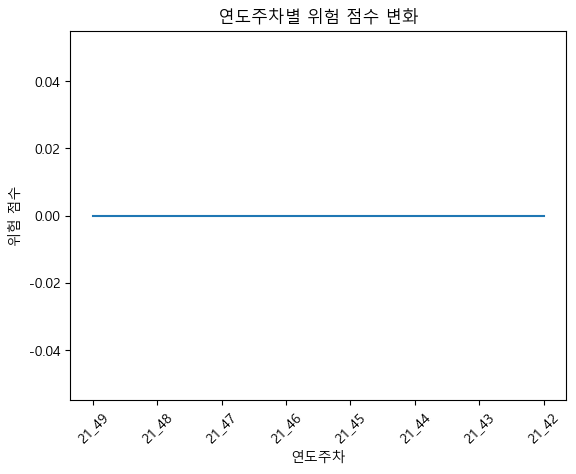

HS Code : 4202211090
21_49주차
      연도주차      단가      신고중량
203  20_51 532.888 52263.671
204  20_52 562.267 47838.790
205  20_53 559.074 43435.399
206  21_01 594.320 44503.772
207  21_02 562.698 42555.229
208  21_03 511.775 49707.213
209  21_04 480.364 56121.919
210  21_05 407.497 68872.104
211  21_06 387.076 71236.824
212  21_07 408.303 66766.088
213  21_08 444.226 64530.305
214  21_09 579.200 49156.903
215  21_10 632.317 48663.179
216  21_11 633.766 48036.599
217  21_12 611.083 50878.901
218  21_13 576.630 53759.516
219  21_14 585.641 51964.728
220  21_15 551.504 55250.921
221  21_16 538.231 54807.624
222  21_17 499.418 60789.986
223  21_18 518.520 62347.020
224  21_19 518.526 64190.178
225  21_20 526.152 61902.435
226  21_21 551.234 57922.386
227  21_22 539.571 57161.986
228  21_23 517.689 58930.013
229  21_24 548.410 57014.098
230  21_25 547.065 56651.065
231  21_26 539.563 57567.049
232  21_27 581.856 54416.429
233  21_28 534.638 59474.312
234  21_29 545.491 56963.876
235  21_30 552

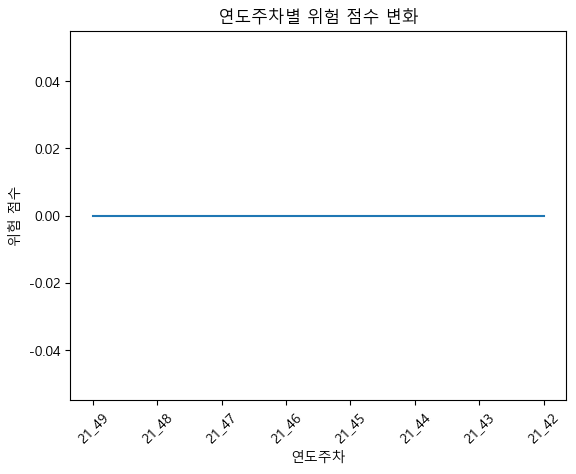

HS Code : 8536509090
21_49주차
      연도주차     단가      신고중량
203  20_51 85.099 60246.861
204  20_52 82.137 59881.584
205  20_53 78.638 55862.932
206  21_01 69.344 57719.618
207  21_02 72.158 57651.495
208  21_03 71.439 62709.417
209  21_04 69.392 73432.723
210  21_05 71.418 76198.813
211  21_06 72.657 69825.888
212  21_07 76.307 61976.343
213  21_08 85.275 53589.749
214  21_09 93.516 46231.214
215  21_10 91.223 52058.659
216  21_11 94.811 53888.197
217  21_12 90.528 55729.191
218  21_13 93.330 58278.385
219  21_14 84.828 60851.425
220  21_15 79.927 63938.195
221  21_16 76.219 68966.169
222  21_17 72.972 71665.670
223  21_18 76.040 68629.845
224  21_19 80.754 66029.588
225  21_20 97.287 64549.445
226  21_21 96.739 64838.267
227  21_22 97.849 69843.178
228  21_23 95.330 73062.585
229  21_24 84.542 72054.022
230  21_25 81.667 73131.471
231  21_26 83.073 68791.433
232  21_27 81.083 70023.747
233  21_28 79.433 72755.953
234  21_29 82.349 68491.653
235  21_30 80.432 69480.282
236  21_31 79.090 6

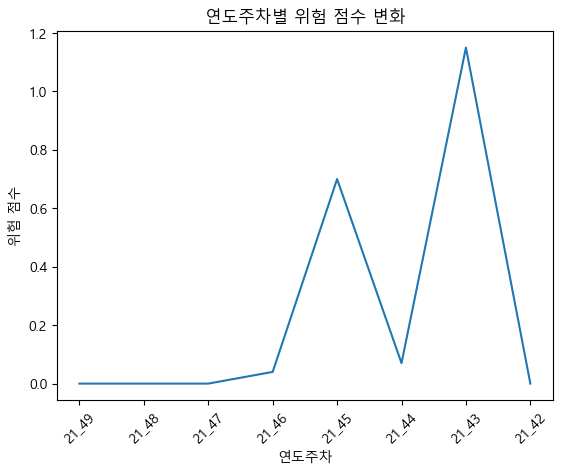

HS Code : 8538909000
21_49주차
      연도주차     단가       신고중량
203  20_51 44.517 199761.115
204  20_52 44.468 199441.904
205  20_53 45.969 187885.608
206  21_01 41.606 194462.358
207  21_02 41.303 191117.803
208  21_03 41.855 200038.034
209  21_04 44.280 208605.636
210  21_05 44.402 216470.493
211  21_06 47.252 197672.697
212  21_07 47.261 188647.886
213  21_08 47.157 182415.817
214  21_09 47.639 181936.029
215  21_10 46.980 198798.902
216  21_11 46.245 210688.322
217  21_12 44.880 222716.960
218  21_13 46.484 224866.703
219  21_14 46.653 221231.820
220  21_15 45.336 226015.939
221  21_16 44.233 229038.843
222  21_17 45.809 218696.898
223  21_18 44.076 224361.777
224  21_19 46.153 208650.944
225  21_20 48.046 205020.536
226  21_21 45.465 205948.316
227  21_22 48.912 198469.953
228  21_23 48.933 208272.869
229  21_24 48.667 207890.690
230  21_25 48.262 207299.203
231  21_26 47.099 211281.924
232  21_27 47.629 211696.081
233  21_28 47.328 204108.060
234  21_29 49.162 200466.252
235  21_30 45.

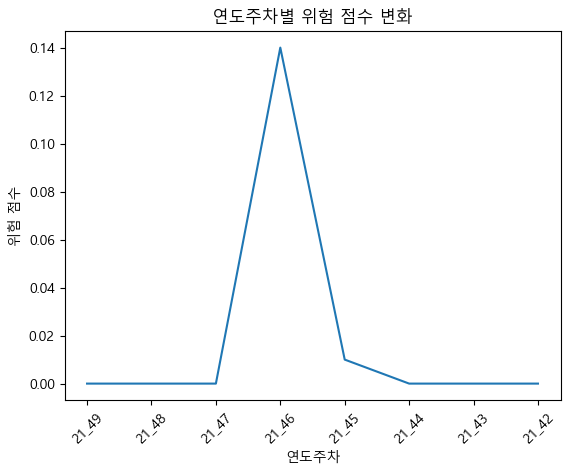

HS Code : 8479909090
21_49주차
      연도주차      단가       신고중량
203  20_51  64.157 112048.781
204  20_52  62.357 126766.957
205  20_53  61.663 125416.917
206  21_01  61.273 105350.832
207  21_02  55.378 100439.274
208  21_03  59.379 103018.610
209  21_04  49.154 151530.944
210  21_05  49.234 163666.752
211  21_06  48.910 160897.102
212  21_07  49.231 143558.380
213  21_08  65.946  93901.027
214  21_09  72.278  84863.768
215  21_10  86.389  82797.873
216  21_11 117.158  79444.750
217  21_12 132.569  75683.794
218  21_13  99.392 108633.485
219  21_14  81.133 128945.313
220  21_15  53.975 143757.616
221  21_16  44.030 154953.597
222  21_17  44.517 142790.867
223  21_18  33.962 203356.607
224  21_19  37.538 191812.873
225  21_20  41.488 204169.511
226  21_21  42.419 189986.617
227  21_22  68.942 115756.440
228  21_23  64.212 121356.489
229  21_24  68.428 102231.066
230  21_25  73.599 112846.854
231  21_26  76.181 114433.980
232  21_27  85.475 115168.452
233  21_28  84.109 119993.733
234  21_29 

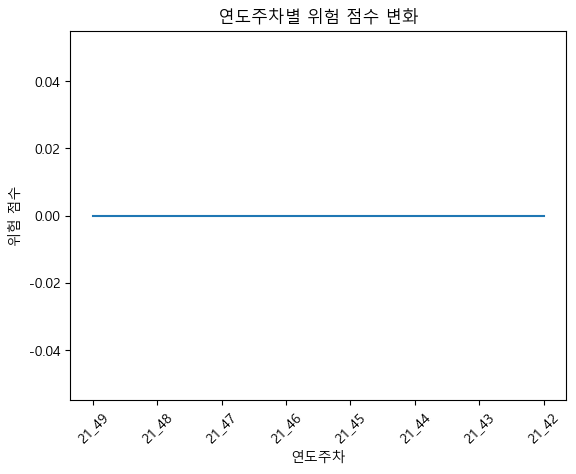

HS Code : 8504409099
21_49주차
      연도주차     단가       신고중량
203  20_51 57.371 216825.794
204  20_52 55.380 199827.486
205  20_53 56.259 179645.250
206  21_01 49.127 193645.123
207  21_02 46.403 196618.522
208  21_03 47.287 195558.510
209  21_04 50.613 208094.351
210  21_05 55.072 201482.680
211  21_06 58.554 171348.328
212  21_07 62.636 151900.337
213  21_08 57.057 161690.884
214  21_09 61.944 156171.154
215  21_10 65.624 168230.079
216  21_11 65.674 183337.540
217  21_12 65.911 185024.951
218  21_13 62.710 189484.781
219  21_14 61.841 206875.188
220  21_15 59.745 212747.092
221  21_16 58.933 207588.165
222  21_17 56.677 216804.356
223  21_18 57.154 205525.343
224  21_19 54.684 217407.987
225  21_20 55.870 215845.767
226  21_21 58.598 207014.077
227  21_22 55.352 205934.674
228  21_23 59.309 186686.059
229  21_24 59.674 180236.845
230  21_25 62.783 169120.167
231  21_26 64.598 171992.050
232  21_27 63.587 165689.307
233  21_28 65.332 163102.634
234  21_29 62.849 168771.955
235  21_30 60.

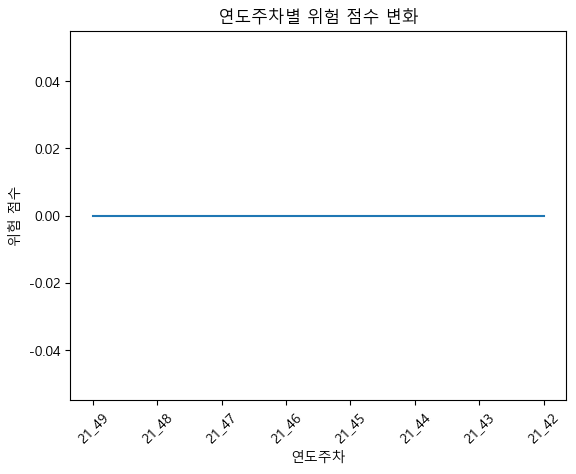

HS Code : 6110909000
21_49주차
      연도주차      단가      신고중량
203  20_51 230.083  8329.869
204  20_52 223.795  8464.396
205  20_53 221.519  7257.489
206  21_01 220.911  6288.368
207  21_02 215.150  6835.757
208  21_03 213.682  6779.111
209  21_04 201.197  8079.757
210  21_05 190.919  9089.175
211  21_06 187.096  8405.817
212  21_07 203.584  8296.678
213  21_08 209.001  8070.520
214  21_09 212.172  7537.493
215  21_10 222.675  7741.536
216  21_11 205.204  7979.335
217  21_12 205.717  7746.431
218  21_13 205.161  7554.070
219  21_14 203.507  7020.086
220  21_15 161.331  9755.739
221  21_16 135.862 11137.030
222  21_17 127.686 11854.092
223  21_18 128.000 11780.782
224  21_19 146.982  8407.641
225  21_20 192.656  6203.400
226  21_21 232.298  5058.238
227  21_22 238.980  4930.196
228  21_23 269.959  4734.483
229  21_24 273.808  4628.604
230  21_25 279.394  4246.866
231  21_26 266.955  4461.281
232  21_27 258.400  4800.432
233  21_28 263.276  4891.676
234  21_29 249.477  5535.059
235  21_30 243

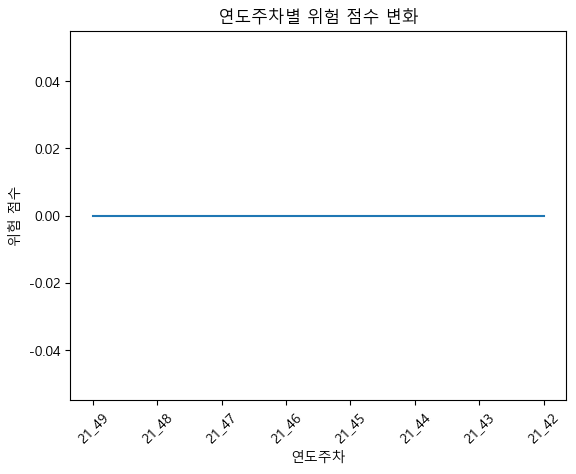

HS Code : 3923100000
21_49주차
      연도주차    단가        신고중량
203  20_51 3.784 2760055.509
204  20_52 3.863 2747754.836
205  20_53 3.893 2656156.484
206  21_01 4.086 2646868.933
207  21_02 4.202 2671309.609
208  21_03 4.231 2683346.298
209  21_04 4.255 2764500.299
210  21_05 3.998 2772380.321
211  21_06 4.134 2513009.629
212  21_07 3.977 2562331.680
213  21_08 3.924 2640499.349
214  21_09 3.838 2539079.478
215  21_10 3.621 2771224.359
216  21_11 3.564 2820960.400
217  21_12 3.571 2744185.470
218  21_13 3.623 2827318.585
219  21_14 3.708 2782199.998
220  21_15 3.721 2740199.480
221  21_16 3.709 2718235.256
222  21_17 3.758 2716759.946
223  21_18 3.701 2716977.223
224  21_19 3.777 2643542.802
225  21_20 3.768 2694008.953
226  21_21 3.754 2668632.471
227  21_22 3.745 2792509.116
228  21_23 3.721 2892573.942
229  21_24 3.823 2788654.483
230  21_25 3.787 2749768.365
231  21_26 3.772 2680352.248
232  21_27 3.759 2664357.786
233  21_28 3.672 2750525.043
234  21_29 3.765 2810178.279
235  21_30 3.8

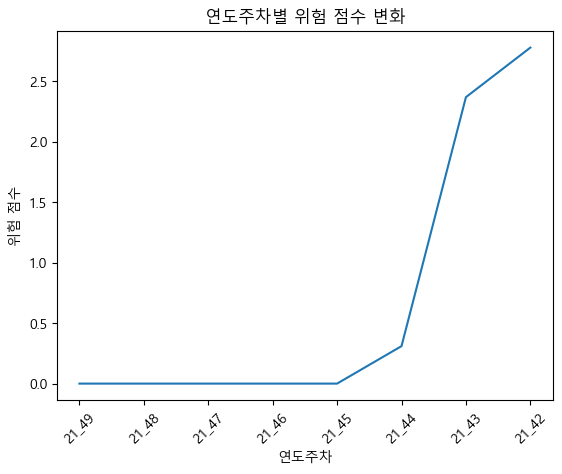

HS Code : 8544422090
21_49주차
      연도주차     단가       신고중량
203  20_51 18.150 592554.243
204  20_52 18.275 594159.720
205  20_53 18.896 542417.829
206  21_01 18.444 555542.468
207  21_02 17.789 575473.396
208  21_03 18.320 556596.500
209  21_04 17.953 608890.774
210  21_05 18.371 619072.457
211  21_06 19.266 596437.152
212  21_07 19.051 587936.560
213  21_08 19.459 535538.496
214  21_09 20.049 502699.259
215  21_10 19.321 529489.940
216  21_11 19.410 551338.563
217  21_12 19.554 609617.063
218  21_13 18.859 651213.323
219  21_14 19.067 662395.741
220  21_15 18.707 679611.653
221  21_16 18.396 690655.017
222  21_17 18.062 704209.197
223  21_18 17.683 708044.196
224  21_19 18.073 693730.049
225  21_20 17.843 693236.784
226  21_21 18.486 648364.668
227  21_22 18.727 651708.669
228  21_23 18.048 658263.496
229  21_24 18.282 642450.528
230  21_25 18.524 637310.535
231  21_26 18.565 641261.290
232  21_27 18.714 646440.738
233  21_28 19.329 644340.554
234  21_29 18.759 658469.509
235  21_30 19.

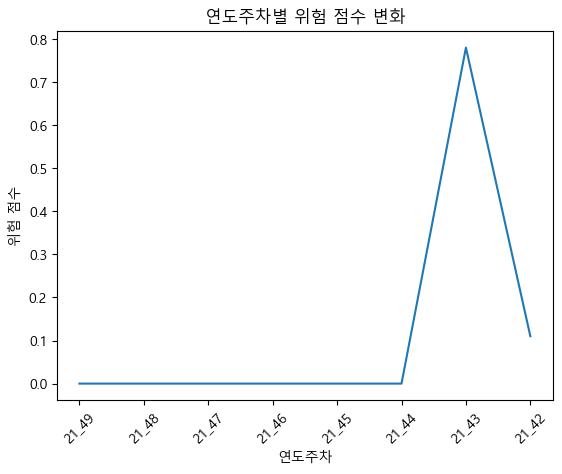

HS Code : 8537109000
21_49주차
      연도주차      단가      신고중량
203  20_51 121.533 74592.855
204  20_52 119.151 73949.129
205  20_53 121.484 68330.765
206  21_01 109.484 69954.558
207  21_02 103.164 68034.449
208  21_03 112.247 64513.579
209  21_04 105.113 77855.183
210  21_05 106.896 76620.841
211  21_06 105.495 77345.098
212  21_07 100.688 85454.958
213  21_08 108.479 73300.009
214  21_09 107.766 76587.261
215  21_10 130.263 78790.947
216  21_11 141.074 69704.942
217  21_12 136.860 72391.245
218  21_13 140.723 68572.360
219  21_14 121.952 64021.203
220  21_15 117.837 64935.287
221  21_16 116.896 65468.412
222  21_17 127.843 62095.634
223  21_18 112.688 77515.754
224  21_19 120.568 73790.957
225  21_20 118.297 78130.993
226  21_21 106.699 80567.066
227  21_22 129.171 67788.136
228  21_23 117.856 75763.816
229  21_24 120.825 71878.339
230  21_25 120.359 72832.569
231  21_26 117.090 67338.546
232  21_27 117.314 67918.086
233  21_28 120.714 68214.203
234  21_29 119.751 72355.603
235  21_30 121

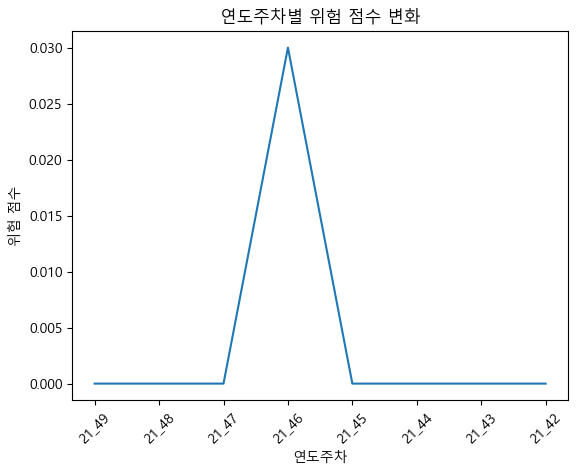

HS Code : 8536699000
21_49주차
      연도주차     단가       신고중량
203  20_51 39.716 128069.363
204  20_52 39.465 127105.610
205  20_53 36.673 130369.402
206  21_01 36.482 122272.494
207  21_02 33.927 137565.283
208  21_03 32.773 149963.333
209  21_04 36.297 144977.549
210  21_05 34.217 166590.883
211  21_06 33.531 159418.604
212  21_07 34.163 152072.122
213  21_08 33.269 151573.824
214  21_09 39.946 117350.798
215  21_10 42.713 116455.800
216  21_11 42.639 112737.595
217  21_12 42.488 120929.632
218  21_13 38.892 138426.899
219  21_14 37.374 146031.757
220  21_15 37.257 153382.350
221  21_16 36.511 152844.359
222  21_17 35.134 154429.435
223  21_18 37.554 140406.318
224  21_19 36.604 136227.571
225  21_20 34.946 144984.728
226  21_21 36.903 137638.730
227  21_22 36.012 145161.396
228  21_23 37.228 147985.332
229  21_24 42.078 128614.835
230  21_25 39.141 137769.859
231  21_26 35.843 149936.850
232  21_27 35.608 142002.905
233  21_28 33.002 163849.396
234  21_29 32.177 170749.419
235  21_30 34.

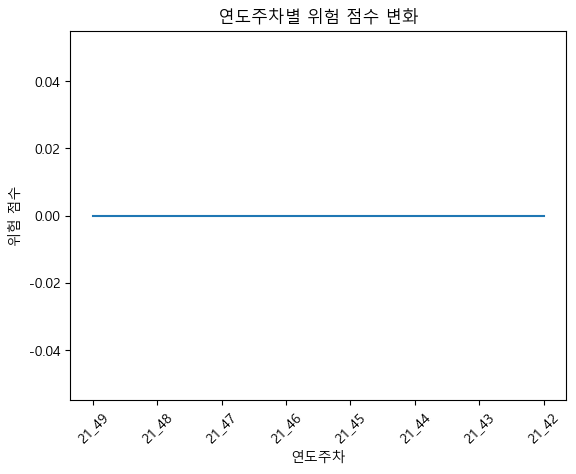

HS Code : 3102109000
21_14주차
      연도주차    단가         신고중량
168  20_16 0.274  7595152.514
169  20_17 0.275  6690618.513
170  20_18 0.273  4845948.741
171  20_19 0.273  5082300.688
172  20_20 0.271  6711051.035
173  20_21 0.269  6433905.144
174  20_22 0.268  7739305.729
175  20_23 0.266  8280687.614
176  20_24 0.263  8150787.332
177  20_25 0.263  8345732.808
178  20_26 0.261  7001619.634
179  20_27 0.258  5895656.384
180  20_28 0.257  5435314.991
181  20_29 0.254  5974286.142
182  20_30 0.252  7965065.094
183  20_31 0.253  9219891.994
184  20_32 0.254  9042738.254
185  20_33 0.254 11076218.961
186  20_34 0.254  8122886.807
187  20_35 0.254  6505523.432
188  20_36 0.256  5793011.707
189  20_37 0.268  3575184.192
190  20_38 0.274  2996353.069
191  20_39 0.278  3415777.144
192  20_40 0.276  2940932.594
193  20_41 0.275  4572083.900
194  20_42 0.273  5892192.336
195  20_43 0.276  8621320.361
196  20_44 0.277 10201257.261
197  20_45 0.278  8196479.362
198  20_46 0.281  6882415.227
199  20_47 

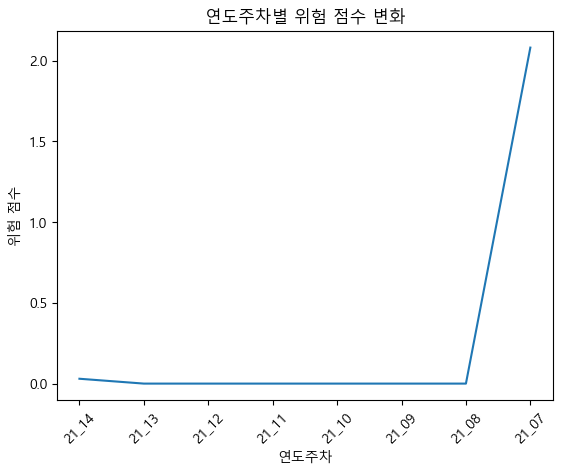

HS Code : 3707901010
19_04주차
      연도주차      단가      신고중량
53   18_05 271.040 20173.728
54   18_06 293.099 20496.747
55   18_07 289.509 19101.228
56   18_08 292.766 18561.987
57   18_09 282.884 19144.031
58   18_10 235.897 23132.675
59   18_11 226.780 26499.160
60   18_12 230.105 24589.869
61   18_13 229.657 24220.195
62   18_14 289.352 21052.534
63   18_15 281.922 22522.304
64   18_16 292.480 26227.010
65   18_17 276.840 24903.522
66   18_18 265.564 20615.000
67   18_19 274.529 19288.663
68   18_20 272.450 18193.278
69   18_21 271.794 18840.737
70   18_22 249.537 22285.820
71   18_23 275.049 20773.943
72   18_24 264.655 20864.880
73   18_25 275.712 20625.178
74   18_26 263.955 20649.105
75   18_27 257.525 22119.247
76   18_28 258.863 21859.940
77   18_29 226.261 24197.684
78   18_30 260.158 23064.973
79   18_31 232.394 23492.327
80   18_32 239.664 25873.863
81   18_33 243.658 23569.524
82   18_34 241.069 23905.783
83   18_35 270.627 22048.571
84   18_36 241.770 23912.596
85   18_37 275

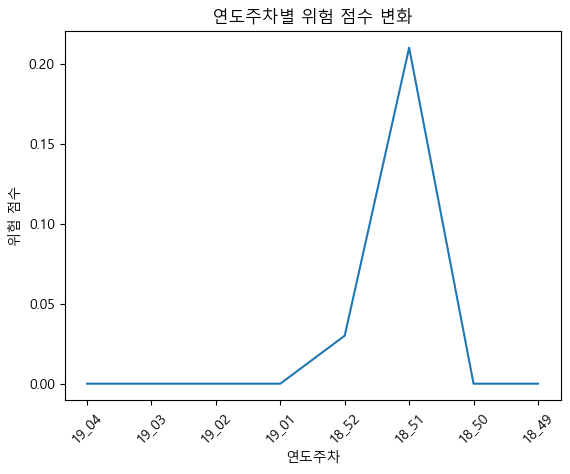

HS Code : 4407191000
20_41주차
      연도주차    단가       신고중량
142  19_42 1.121 142855.500
143  19_43 1.127 167602.578
144  19_44 1.129 172108.328
145  19_45 1.277 151083.578
146  19_46 1.320 195233.725
147  19_47 1.341 168487.397
148  19_48 1.338 192482.647
149  19_49 1.299 201823.397
150  19_50 1.252 183001.500
151  19_51 1.252 199930.250
152  19_52 1.259 172237.330
153  20_01 1.247 189899.330
154  20_02 1.240 200884.830
155  20_03 1.188 214903.655
156  20_04 1.127 264579.340
157  20_05 1.129 275269.840
158  20_06 1.127 236470.223
159  20_07 1.160 208230.898
160  20_08 1.237 122825.633
161  20_09 1.268  91211.383
162  20_10 1.253  94948.500
163  20_11 1.261 138382.343
164  20_12 1.290 188889.978
165  20_13 1.208 240923.167
166  20_14 1.205 245405.167
167  20_15 1.207 255033.016
168  20_16 1.168 232849.132
169  20_17 1.273 208142.443
170  20_18 1.278 212974.443
171  20_19 1.296 174660.487
172  20_20 1.307 192153.237
173  20_21 1.282 174147.462
174  20_22 1.246 208127.462
175  20_23 1.225 19

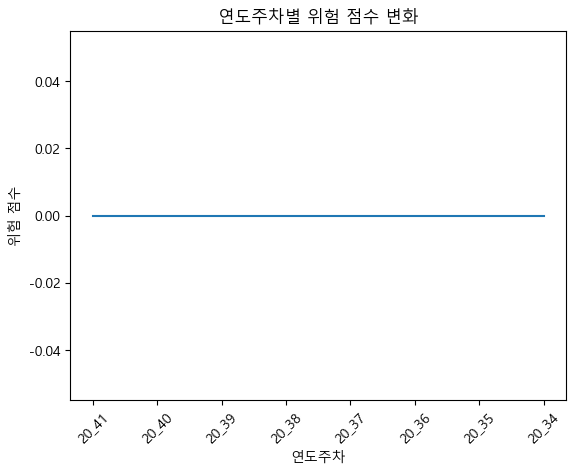

HS Code : 8111000000
21_19주차
      연도주차    단가        신고중량
173  20_21 1.538 2411149.567
174  20_22 1.546 2243092.258
175  20_23 1.543 2094445.660
176  20_24 1.550 1657916.090
177  20_25 1.577 1245858.371
178  20_26 1.559 1534800.232
179  20_27 1.580 1307604.550
180  20_28 1.593 1293489.455
181  20_29 1.562 1212797.974
182  20_30 1.523 1030512.490
183  20_31 1.464 1799550.890
184  20_32 1.446 1732697.468
185  20_33 1.460 1666406.519
186  20_34 1.466 1451579.890
187  20_35 1.516  881444.005
188  20_36 1.498 1486463.236
189  20_37 1.465 1926003.335
190  20_38 1.462 2151619.315
191  20_39 1.457 2236845.100
192  20_40 1.449 1560972.306
193  20_41 1.502 1526437.145
194  20_42 1.525 1216028.464
195  20_43 1.526 1503132.158
196  20_44 1.536 1716228.895
197  20_45 1.513 1499314.407
198  20_46 1.520 1864895.908
199  20_47 1.529 1838912.570
200  20_48 1.524 1881359.907
201  20_49 1.523 2331514.192
202  20_50 1.519 2123058.496
203  20_51 1.540 1726439.953
204  20_52 1.577 2127137.453
205  20_53 1.6

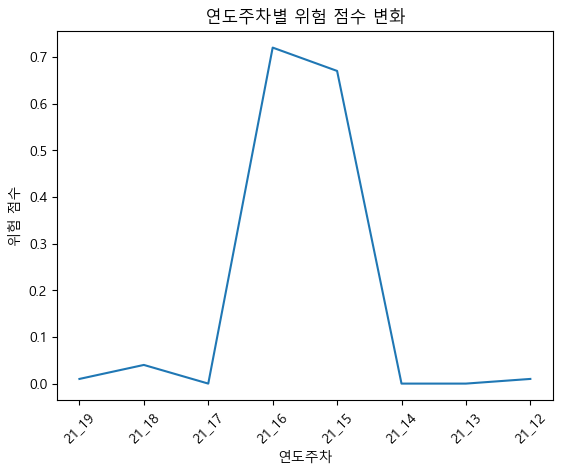

HS Code : 2701129010
21_25주차
      연도주차    단가          신고중량
179  20_27 0.105  77669185.200
180  20_28 0.106 120276473.100
181  20_29 0.109 144388042.100
182  20_30 0.105 164400070.350
183  20_31 0.104 169156920.350
184  20_32 0.104 155045125.750
185  20_33 0.100 173889515.750
186  20_34 0.104 152513175.000
187  20_35 0.107 157102201.460
188  20_36 0.104 174937717.460
189  20_37 0.104 158211262.460
190  20_38 0.096 222905251.404
191  20_39 0.098 226670762.444
192  20_40 0.097 186675146.444
193  20_41 0.097 187277646.444
194  20_42 0.100 156835390.000
195  20_43 0.095 162396417.250
196  20_44 0.096 158470734.750
197  20_45 0.101 206851071.829
198  20_46 0.105 200732196.329
199  20_47 0.105 230270214.079
200  20_48 0.104 244174568.017
201  20_49 0.111 200210940.938
202  20_50 0.106 189521504.668
203  20_51 0.107 157750269.985
204  20_52 0.107 219737703.548
205  20_53 0.103 225731607.798
206  21_01 0.107 183787999.567
207  21_02 0.107 224709651.750
208  21_03 0.110 202500680.500
209  21_04

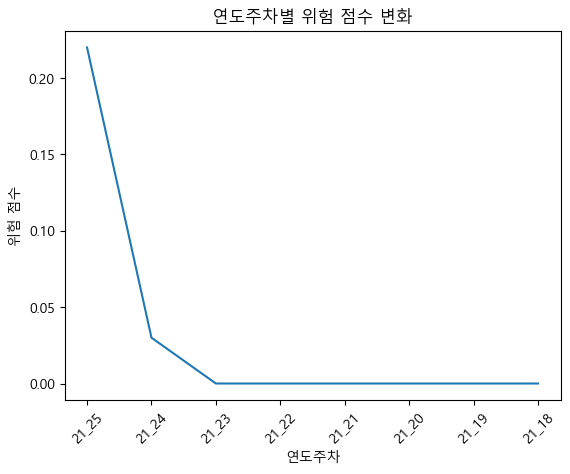

HS Code : 2804701000
21_25주차
      연도주차    단가       신고중량
179  20_27 3.132 202037.500
180  20_28 3.061 194845.000
181  20_29 3.033 185672.500
182  20_30 3.104 251832.500
183  20_31 3.077 203832.500
184  20_32 3.083 198382.500
185  20_33 3.106 187587.500
186  20_34 3.078 154830.000
187  20_35 3.124 172505.000
188  20_36 3.050 170010.000
189  20_37 3.092 193452.500
190  20_38 3.035 160070.000
191  20_39 3.008 140782.500
192  20_40 3.051 170230.000
193  20_41 3.076 174225.000
194  20_42 3.085 213700.000
195  20_43 3.012 257400.000
196  20_44 3.027 214935.000
197  20_45 2.965 207790.000
198  20_46 2.976 216800.000
199  20_47 3.003 149527.500
200  20_48 2.965 212565.000
201  20_49 2.951 203110.000
202  20_50 2.920 209822.500
203  20_51 2.930 240420.000
204  20_52 2.884 253835.025
205  20_53 2.941 254742.525
206  21_01 3.446 178310.470
207  21_02 3.332 196105.482
208  21_03 3.499 147182.957
209  21_04 3.310 187867.957
210  21_05 2.799 262452.513
211  21_06 2.863 280122.500
212  21_07 2.831 25

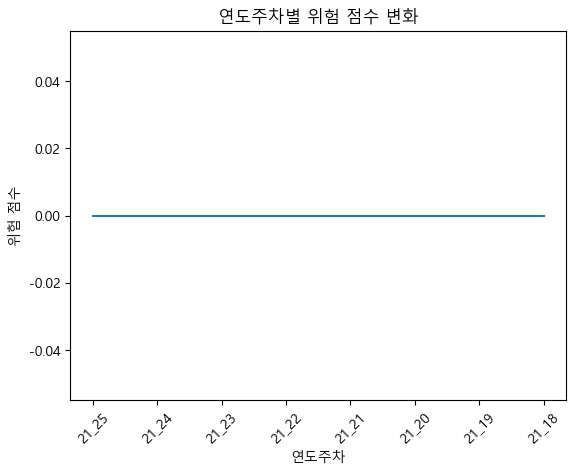

HS Code : 1511901000
21_29주차
      연도주차    단가        신고중량
183  20_31 0.621 1262809.750
184  20_32 0.643  149505.000
185  20_33 0.646  492634.500
186  20_34 0.620 1029870.750
187  20_35 0.620 1029830.375
188  20_36 0.633 1533380.425
189  20_37 0.627 1570067.175
190  20_38 0.642 1172577.175
191  20_39 0.653 1297327.624
192  20_40 0.646  787420.574
193  20_41 0.699  275626.824
194  20_42 0.680  622862.725
195  20_43 0.695  801885.201
196  20_44 0.698  926696.951
197  20_45 0.730 1303057.951
198  20_46 0.771 1215280.800
199  20_47 0.784 1492678.275
200  20_48 0.794 1375801.525
201  20_49 0.788  999440.631
202  20_50 0.843 1263995.631
203  20_51 0.879  963353.856
204  20_52 0.869 1457994.656
205  20_53 0.869 1457994.550
206  21_01 0.905 1537650.550
207  21_02 0.919 1535177.550
208  21_03 0.948 1032601.750
209  21_04 0.938 1655937.250
210  21_05 0.929  901391.250
211  21_06 0.964  973333.000
212  21_07 0.970 1148300.000
213  21_08 1.038 1083733.000
214  21_09 1.039 1088981.800
215  21_10 1.0

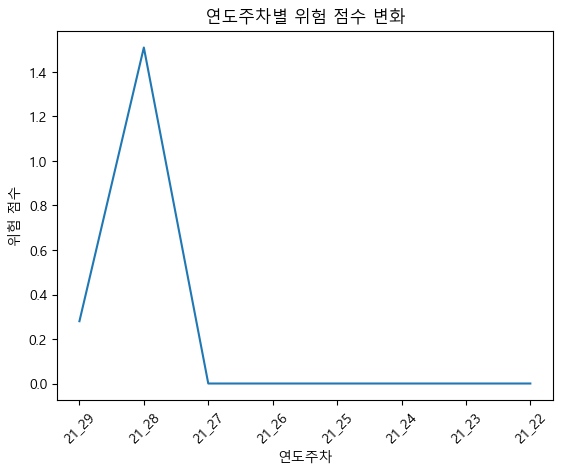

HS Code : 305531000
21_34주차
      연도주차     단가       신고중량
188  20_36 10.457 156099.745
189  20_37 10.291 164037.820
190  20_38 10.331 163524.378
191  20_39 10.352 155503.128
192  20_40 10.652 141043.857
193  20_41 10.680 139208.357
194  20_42 10.556 138356.500
195  20_43 10.204 163140.750
196  20_44 10.238 196490.750
197  20_45  9.965 203363.500
198  20_46  9.833 196634.500
199  20_47 10.247 166431.098
200  20_48 10.184 157746.348
201  20_49 10.669 151943.742
202  20_50 10.382 153117.812
203  20_51 10.074 168043.858
204  20_52 10.266 182001.148
205  20_53  9.824 188950.253
206  21_01 10.194 180399.433
207  21_02 10.391 177167.290
208  21_03  9.905 144132.675
209  21_04  9.881 127121.125
210  21_05  9.969 144520.875
211  21_06  9.967 123379.325
212  21_07  9.942 127691.400
213  21_08 10.309 109895.575
214  21_09 10.195  94605.349
215  21_10 10.037 119550.149
216  21_11 10.390 125476.449
217  21_12 10.453 146197.870
218  21_13 10.162 150753.546
219  21_14  9.852 140290.640
220  21_15  9.6

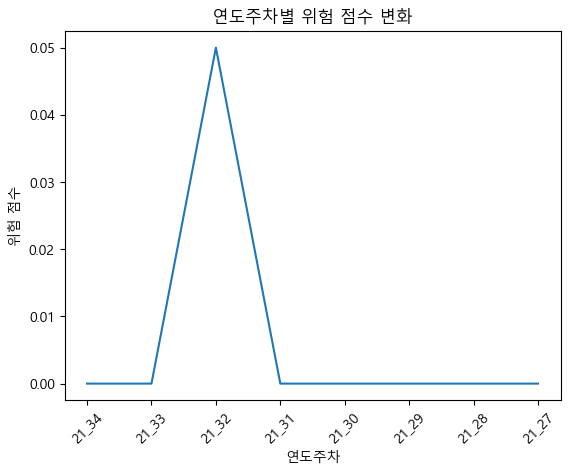

HS Code : 302140000
21_35주차
      연도주차     단가       신고중량
189  20_37  9.204 432161.413
190  20_38  9.142 457808.887
191  20_39  9.207 494310.018
192  20_40  9.397 518436.598
193  20_41  9.213 520939.741
194  20_42  8.929 515701.217
195  20_43  8.595 509818.949
196  20_44  8.103 509845.362
197  20_45  7.817 511369.361
198  20_46  7.567 511072.253
199  20_47  7.347 511432.891
200  20_48  7.301 516992.998
201  20_49  7.314 505040.093
202  20_50  7.361 514337.020
203  20_51  7.389 515077.465
204  20_52  7.522 554803.830
205  20_53  7.879 590383.615
206  21_01  8.235 599942.585
207  21_02  8.375 594274.117
208  21_03  8.449 564973.938
209  21_04  8.298 556900.944
210  21_05  8.031 560299.449
211  21_06  7.962 559853.442
212  21_07  8.044 567748.774
213  21_08  8.228 588090.171
214  21_09  8.719 590361.155
215  21_10  9.300 615575.662
216  21_11  9.672 615668.297
217  21_12  9.979 608740.494
218  21_13 10.184 627113.382
219  21_14 10.329 585409.915
220  21_15 10.529 590562.853
221  21_16 10.7

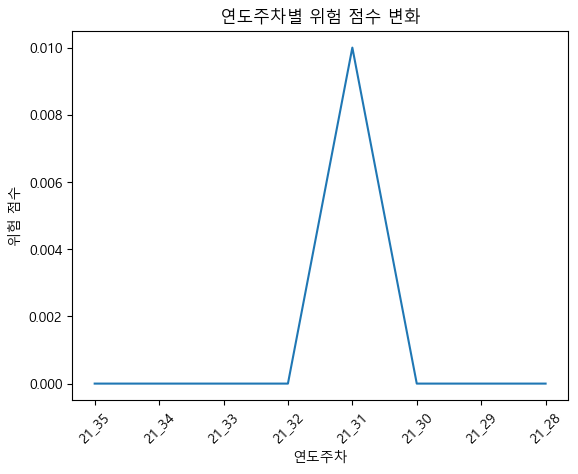

HS Code : 1003901000
21_34주차
      연도주차    단가        신고중량
188  20_36 0.236  540667.500
189  20_37 0.236  540667.500
190  20_38 0.231 1053037.750
191  20_39 0.233 1170537.750
192  20_40 0.234  639870.250
193  20_41 0.234  639870.250
194  20_42 0.258  117500.000
195  20_43 0.285   56103.500
196  20_44 0.285   56103.500
197  20_45 0.241  263538.500
198  20_46 0.241  528096.500
199  20_47 0.233  679440.500
200  20_48 0.237 1055146.750
201  20_49 0.238  951616.750
202  20_50 0.240  842628.525
203  20_51 0.238  947456.025
204  20_52 0.232  881299.775
205  20_53 0.232  984647.275
206  21_01 0.229  932840.000
207  21_02 0.229  620565.000
208  21_03 0.223  727777.500
209  21_04 0.221  520525.000
210  21_05 0.218  624857.500
211  21_06 0.218  833205.000
212  21_07 0.216  623622.500
213  21_08 0.216  932005.000
214  21_09 0.216  828835.000
215  21_10 0.217  717547.500
216  21_11 0.217  615187.500
217  21_12 0.217  411495.000
218  21_13 0.217  364135.000
219  21_14 0.216  267075.000
220  21_15 0.2

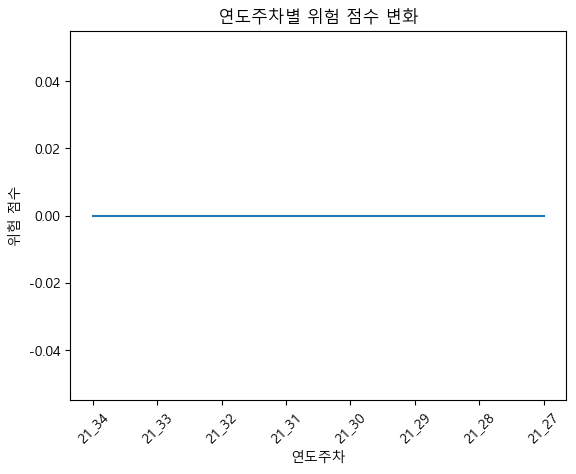

HS Code : 1003902000
21_34주차
      연도주차    단가        신고중량
188  20_36 0.284  108114.500
189  20_37 0.252   80120.000
190  20_38 0.238  154445.000
191  20_39 0.228  149445.000
192  20_40 0.224  100475.000
193  20_41 0.224  100450.000
194  20_42 0.228   26125.000
195  20_43 0.285   56032.500
196  20_44 0.266   83782.500
197  20_45 0.244  161507.500
198  20_46 0.243  167257.500
199  20_47 0.218  189280.000
200  20_48 0.217  161530.000
201  20_49 0.206  109610.000
202  20_50 0.210  131335.000
203  20_51 0.211  199960.000
204  20_52 0.213  227122.500
205  20_53 0.215  175192.500
206  21_01 0.217  255790.000
207  21_02 0.224  135235.000
208  21_03 0.225  153807.500
209  21_04 0.242  998147.500
210  21_05 0.249 3067715.000
211  21_06 0.250 3253485.000
212  21_07 0.250 3652617.500
213  21_08 0.250 2992217.500
214  21_09 0.244  869097.500
215  21_10 0.239  683327.500
216  21_11 0.236  269977.500
217  21_12 0.247  164995.000
218  21_13 0.254  298164.750
219  21_14 0.254  298164.750
220  21_15 0.2

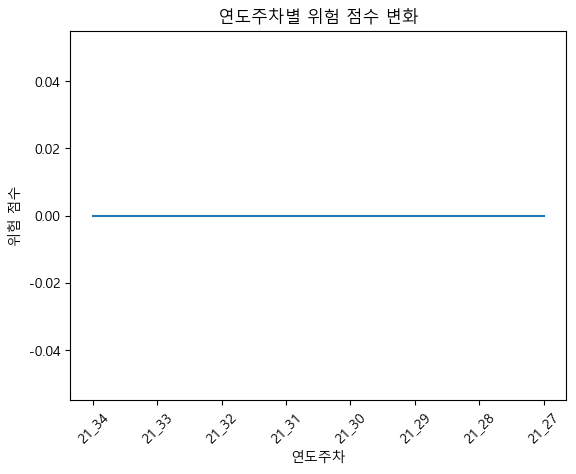

HS Code : 1104230000
21_34주차
      연도주차    단가       신고중량
188  20_36 0.397 294500.625
189  20_37 0.396 384750.000
190  20_38 0.391 429250.000
191  20_39 0.394 516750.612
192  20_40 0.406 491500.612
193  20_41 0.404 562650.613
194  20_42 0.409 560900.613
195  20_43 0.406 502150.000
196  20_44 0.402 432400.000
197  20_45 0.392 332750.500
198  20_46 0.383 256750.500
199  20_47 0.359 180500.500
200  20_48 0.359 217313.000
201  20_49 0.359 112812.500
202  20_50 0.359  79567.800
203  20_51 0.360  36817.800
204  20_52 6.909     12.050
205  20_53 8.119     24.725
206  21_01 0.416 365769.425
207  21_02 0.402 498780.800
208  21_03 0.403 577286.988
209  21_04 0.400 667524.312
210  21_05 0.377 368274.537
211  21_06 0.386 235263.788
212  21_07 0.402 449250.850
213  21_08 0.407 359001.392
214  21_09 0.415 432751.167
215  21_10 0.410 475500.542
216  21_11 0.404 323250.542
217  21_12 0.412 405750.000
218  21_13 0.411 345500.125
219  21_14 0.414 364500.125
220  21_15 0.410 295501.375
221  21_16 0.424 25

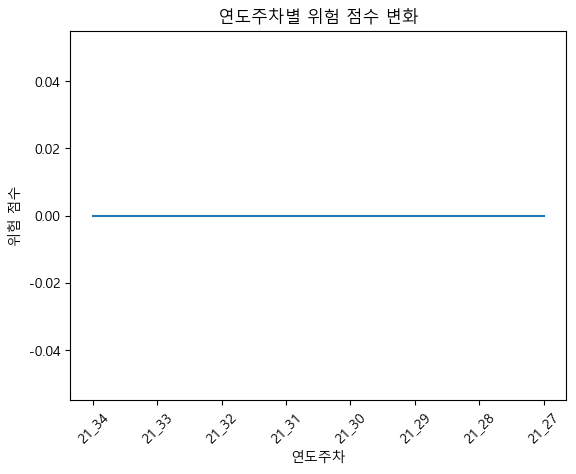

HS Code : 2710121000
21_34주차
      연도주차    단가         신고중량
188  20_36 0.425  2512617.750
189  20_37 0.427  3666846.750
190  20_38 0.425 10449924.250
191  20_39 0.423 11686274.025
192  20_40 0.424  9174659.025
193  20_41 0.415 10728342.025
194  20_42 0.395  6959541.775
195  20_43 0.388 10025896.500
196  20_44 0.388 10462598.000
197  20_45 0.386  7754686.000
198  20_46 0.382  6958469.125
199  20_47 0.382  4186783.455
200  20_48 0.387  6381777.955
201  20_49 0.395 10343325.705
202  20_50 0.402  9071506.830
203  20_51 0.405  7539637.250
204  20_52 0.410  4907941.250
205  20_53 0.435  1940405.750
206  21_01 0.481  3015398.500
207  21_02 0.480  3015246.500
208  21_03 0.460  7815153.500
209  21_04 0.485 10787000.250
210  21_05 0.482  8765766.000
211  21_06 0.505 15930045.000
212  21_07 0.530 11130138.000
213  21_08 0.556 12556530.250
214  21_09 0.557 12704250.250
215  21_10 0.587  5539971.250
216  21_11 0.587  5569408.000
217  21_12 0.598   177156.750
218  21_13 0.633  1138045.250
219  21_14 

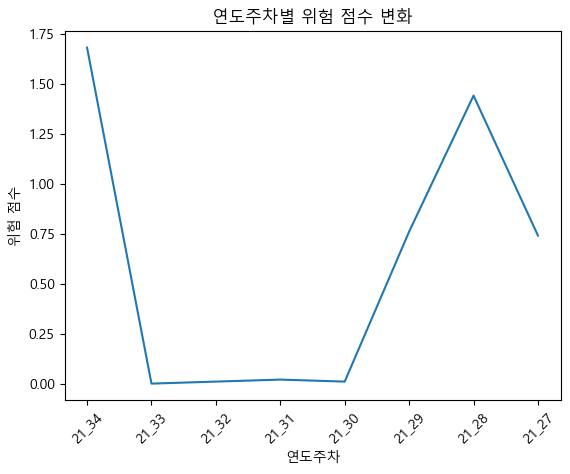

HS Code : 3104200000
21_34주차
      연도주차    단가         신고중량
188  20_36 0.265  7729349.763
189  20_37 0.264  7679388.240
190  20_38 0.267  8524892.264
191  20_39 0.265  8463893.514
192  20_40 0.265  8984880.827
193  20_41 0.266  9816516.402
194  20_42 0.265  8973060.845
195  20_43 0.264  8956468.158
196  20_44 0.301   841401.158
197  20_45 0.266 15676446.743
198  20_46 0.267 17504398.025
199  20_47 0.267 17535235.902
200  20_48 0.267 17657580.584
201  20_49 0.286  2015822.659
202  20_50 0.304  1023508.009
203  20_51 0.268 10098557.994
204  20_52 0.269  9985289.768
205  20_53 0.270 12138499.133
206  21_01 0.267 19295637.995
207  21_02 0.270 10245594.258
208  21_03 0.269 11439086.318
209  21_04 0.268 10078878.595
210  21_05 0.273 17623980.602
211  21_06 0.271 18941973.165
212  21_07 0.272 19154089.112
213  21_08 0.269 26388053.882
214  21_09 0.265 10848408.987
215  21_10 0.271 10939364.025
216  21_11 0.268 17474054.190
217  21_12 0.272  9429601.715
218  21_13 0.261 23952649.830
219  21_14 

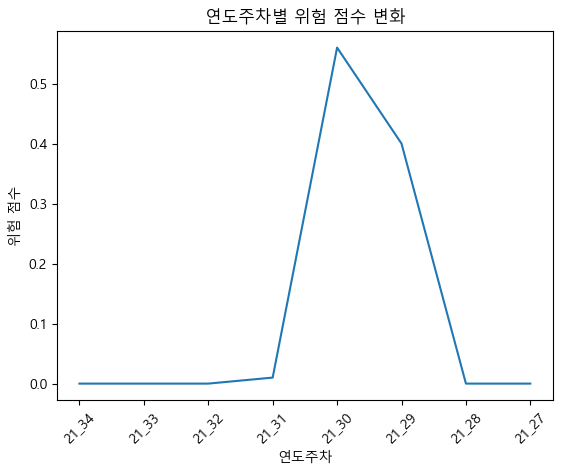

HS Code : 2905172000
21_43주차
      연도주차    단가       신고중량
197  20_45 1.418  96282.475
198  20_46 1.404  85889.725
199  20_47 1.404  91147.250
200  20_48 1.385  98423.050
201  20_49 1.572  81478.300
202  20_50 1.555  78796.050
203  20_51 1.567  83173.275
204  20_52 1.605  87809.250
205  20_53 1.475  68608.075
206  21_01 1.488  80663.725
207  21_02 1.527  66336.850
208  21_03 1.552  49280.600
209  21_04 1.537  73217.605
210  21_05 1.632  71739.255
211  21_06 1.652  70456.130
212  21_07 1.632  79374.883
213  21_08 1.721  70663.053
214  21_09 1.638  73585.628
215  21_10 1.687  86598.553
216  21_11 1.763 112124.425
217  21_12 1.750 114662.050
218  21_13 1.776 105335.050
219  21_14 1.813  90309.875
220  21_15 1.771  77989.250
221  21_16 1.838  59863.625
222  21_17 1.870 102581.150
223  21_18 1.868 104593.403
224  21_19 1.884 103831.328
225  21_20 1.888 105693.828
226  21_21 1.972  74423.258
227  21_22 1.982  78403.830
228  21_23 2.164  91800.905
229  21_24 2.211  79802.405
230  21_25 2.363  6

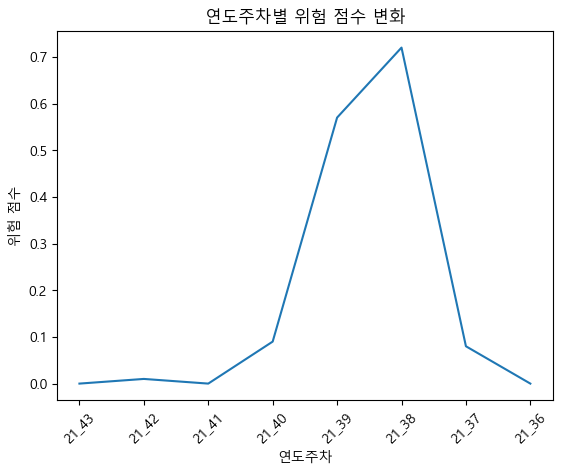

[0, 0, np.float64(0.57), np.float64(0.12), 0, 0, 0, 0, 0, np.float64(2.31), np.float64(0.05), 0, np.float64(2.81), 0, np.float64(0.02), np.float64(0.04), np.float64(0.01), np.float64(0.94), np.float64(0.23), 0, np.float64(0.02), 0, np.float64(4.36), np.float64(0.06), 0, 0, np.float64(1.15), np.float64(0.14), 0, 0, 0, np.float64(2.78), np.float64(0.78), np.float64(0.03), 0, np.float64(2.08), np.float64(0.21), 0, np.float64(0.72), np.float64(0.22), 0, np.float64(1.51), np.float64(0.05), np.float64(0.01), 0, 0, 0, np.float64(1.68), np.float64(0.56), np.float64(0.72)]
[0, 0, 48, 43, 0, 0, 0, 0, 0, 48, 48, 0, 46, 0, 45, 48, 47, 45, 48, 0, 44, 0, 46, 42, 0, 0, 48, 45, 0, 0, 0, 49, 48, 45, 0, 84, 197, 0, 75, 66, 0, 63, 59, 60, 0, 0, 0, 57, 61, 53]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [3]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        print(df_price_4w.iloc[p_eriod-l:-l])
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['단가'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['단가'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['단가'] - data_mean) / data_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

        #=================== 신고중량 percertile 구하기 ====================
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['신고중량'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['신고중량'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['신고중량'] - data_mean ) / data_std
        x=np.exp((scipy.stats.norm.cdf(abs(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y       
    
    if(z[j]<1.85):
        o[j] = 1
    
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)
print(k)



# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model1(1)'] = o
collect.loc[50, 'Model1(1)'] = np.sum(o)
collect.loc[:49, 'Model1(2)'] = z
collect.loc[50, 'Model1(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[2]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[2]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[2]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)